#### Created by : Shaik Muzubur Rahaman

Render Url - https://product-recommendation-system-8kuq.onrender.com/

## Problem Statement:

The e-commerce business is quite popular today. Here, you do not need to take orders by going to each customer. A company launches its website to sell the items to the end consumer, and customers can order the products that they require from the same website. Famous examples of such e-commerce companies are Amazon, Flipkart, Myntra, Paytm and Snapdeal.

Suppose you are working as a Machine Learning Engineer in an e-commerce company named 'Ebuss'. Ebuss has captured a huge market share in many fields, and it sells the products in various categories such as household essentials, books, personal care products, medicines, cosmetic items, beauty products, electrical appliances, kitchen and dining products and health care products.

With the advancement in technology, it is imperative for Ebuss to grow quickly in the e-commerce market to become a major leader in the market because it has to compete with the likes of Amazon, Flipkart, etc., which are already market leaders.

As a senior ML Engineer, you are asked to build a model that will improve the recommendations given to the users given their past reviews and ratings.

In order to do this, you planned to build a sentiment-based product recommendation system, which includes the following tasks.

   1. Data sourcing and sentiment analysis
   2. Building a recommendation system
   3. Improving the recommendations using the sentiment analysis model
   4. Deploying the end-to-end project with a user interface

### Steps involved in the project
# Project Objectives

The key objectives of this project are:

## 1. Analyze and Preprocess Customer Review Data

- Perform **Exploratory Data Analysis (EDA)**
- Clean and preprocess textual reviews
- Handle missing values
- Handle class imbalance

## 2. Build a Sentiment Analysis Model

- Convert textual reviews into numerical features using techniques such as:
  - **TF-IDF**

- Train and evaluate multiple machine learning models:
  - Logistic Regression  
  - Random Forest  
  - XGBoost  
  - Naive Bayes  

- Select the best-performing model based on evaluation metrics

## 3. Develop a Recommendation System

Implement:

- **User-Based Collaborative Filtering**
- **Item-Based Collaborative Filtering**

Tasks:

- Evaluate both recommendation systems
- Select the most suitable model
- Generate **Top 20 product recommendations** for each user based on ratings

## 4. Improve Recommendations Using Sentiment Analysis**

- Apply the trained sentiment model to the reviews of the Top 20 recommended products
- Filter and rank these products
- Generate the **Top 5 products** with the highest positive sentiment

## 5. Deploy the End-to-End System

- Integrate the sentiment analysis model with the recommendation engine
- Build a **Flask-based web application**
- Deploy the application on a cloud platform (Heroku or equivalent)
- Provide a user interface where:
  - An existing username can be entered
  - Personalized recommendations are displayed


#### Assumption: No new users or products will be introduced or considered when building or predicting from the models built.



# Dataset Description

**id** - Unique identity number to identify each unique review given by the user to a particular product in the dataset  

**brand** - Name of the brand of the product to which the user has given a review and rating  

**categories** - Category of the product such as household essentials, books, personal care products, medicines, cosmetic items, beauty products, electrical appliances, kitchen and dining products, health care products, and many more  

**manufacturer** - Name of the manufacturer of the product  

**name** - Name of the product to which the user has added a review or rating  

**reviews_date** - Date on which the review has been added by the user  

**reviews_didPurchase** - Whether a particular user has purchased the product or not  

**reviews_doRecommend** - Whether a particular user has recommended the product or not  

**reviews_rating** - Rating given by the user to a particular product  

**reviews_text** - Review given by the user to a particular product  

**reviews_title** - Title of the review given by the user to a particular product  

**reviews_userCity** - The residing city of the user  

**reviews_userProvince** - The residing province of the user  

**reviews_username** - The unique identification for an individual user in the dataset  

**user_sentiment** - The overall sentiment of the user for a particular product (Positive or Negative)  


## 1. Importing Necessary libraries





In [7]:
import numpy as np
import pandas as pd
import sklearn
import scipy
import xgboost
import seaborn
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import string
import re
from math import sqrt

import spacy
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,MinMaxScaler


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import  balanced_accuracy_score,accuracy_score,precision_score,recall_score,f1_score,roc_curve,confusion_matrix,classification_report,roc_auc_score,pairwise_distances
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, GridSearchCV

import pickle
import os

from scipy.stats import loguniform

import warnings
warnings.filterwarnings("ignore")

In [8]:
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("spacy:", spacy.__version__)
print("nltk:", nltk.__version__)
print("scipy:", scipy.__version__)



numpy: 2.0.2
pandas: 2.2.2
matplotlib: 3.10.0
seaborn: 0.13.2
scikit-learn: 1.6.1
xgboost: 3.2.0
spacy: 3.8.11
nltk: 3.9.1
scipy: 1.17.1


In [9]:
!python -m spacy download en_core_web_sm

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to C:\Users\MUZUBUR
[nltk_data]     RAHAMAN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\MUZUBUR
[nltk_data]     RAHAMAN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\MUZUBUR
[nltk_data]     RAHAMAN\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [11]:
def save_pickle_model(model, directory, filename):
    """
    Saves a model object to a specified directory and filename.
    """
    # 1. Create the directory if it doesn't exist
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Created directory: {directory}")

    # 2. Define the full path
    full_path = os.path.join(directory, filename)

    # 3. Save the model
    with open(full_path, 'wb') as f:
        pickle.dump(model, f)

    print(f"✅ Model saved successfully at: {full_path}")

## 2. Load Dataset

In [12]:
# Read review csv file
reviews_df = pd.read_csv("sample30.csv")

In [13]:
reviews_df.sample(5)

,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment
22811,AVpfov9TLJeJML43A7B0,Bisquick,"Food & Beverage,Baking & Cooking Essentials,Ba...","GENERAL MILLS SALES, INC.",Bisquick Original Pancake And Baking Mix - 40oz,2014-11-30T00:00:00.000Z,False,True,5,I love Bisquick. It can be used for so many th...,So GOOD!!,NaN,NaN,glennschicken,Positive
26501,AVpfPPkEilAPnD_xX3cP,Aveeno,"Personal Care,Sun Care,Featured Brands,Health ...",Aveeno Baby,Aveeno Baby Continuous Protection Lotion Sunsc...,2016-12-12T00:00:00.000Z,NaN,NaN,1,Bought the sunscreen. Didn't like it. Baby's s...,Disappointed,NaN,NaN,byamazon customer,Positive
4253,AVpe9W4D1cnluZ0-avf0,Hoover,"Home,Home Appliances,Vacuums & Floor Care,Upri...",Hoover,Hoover174 Platinum Collection153 Lightweight B...,2013-09-04T00:00:00.000Z,True,True,5,was looking around for a bagged vacuum. Read s...,Great vacuum,NaN,NaN,wwphf,Positive
21810,AVpfm8yiLJeJML43AYyu,Nexxus,"Personal Care,Hair Care,Styling Gel/Lotion,Bea...",Nexxus Beauty Products,Nexxus Exxtra Gel Style Creation Sculptor,2010-04-01T16:36:33.000Z,NaN,True,5,I have curly hair and this gel gives me great ...,Love This Gel,Riverside,CA,emmy,Positive
1970,AVpe41TqilAPnD_xQH3d,FOX,"Movies & TV Shows,Movies,Romance,Romantic Come...",Twentieth Century Fox,Mike Dave Need Wedding Dates (dvd + Digital),2016-10-28T00:00:00.000Z,NaN,True,4,Funny but not as in a theater I would still bu...,Funny,NaN,NaN,feelgood2000,Positive


In [14]:
# Display basic information about the dataset
print("Dataset Shape:", reviews_df.shape)
print("\nColumn Names:")
print(reviews_df.columns.tolist())
print("\nFirst few rows:")
reviews_df.head()

Dataset Shape: (30000, 15)

Column Names:
['id', 'brand', 'categories', 'manufacturer', 'name', 'reviews_date', 'reviews_didPurchase', 'reviews_doRecommend', 'reviews_rating', 'reviews_text', 'reviews_title', 'reviews_userCity', 'reviews_userProvince', 'reviews_username', 'user_sentiment']

First few rows:


,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the...,Just Awesome,Los Angeles,NaN,joshua,Positive
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part...,Good,NaN,NaN,dorothy w,Positive
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor.,Good,NaN,NaN,dorothy w,Positive
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06T00:00:00.000Z,False,False,1,I read through the reviews on here before look...,Disappointed,NaN,NaN,rebecca,Negative
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21T00:00:00.000Z,False,False,1,My husband bought this gel for us. The gel cau...,Irritation,NaN,NaN,walker557,Negative


## 3. Data Cleaning

In [15]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    30000 non-null  object
 1   brand                 30000 non-null  object
 2   categories            30000 non-null  object
 3   manufacturer          29859 non-null  object
 4   name                  30000 non-null  object
 5   reviews_date          29954 non-null  object
 6   reviews_didPurchase   15932 non-null  object
 7   reviews_doRecommend   27430 non-null  object
 8   reviews_rating        30000 non-null  int64 
 9   reviews_text          30000 non-null  object
 10  reviews_title         29810 non-null  object
 11  reviews_userCity      1929 non-null   object
 12  reviews_userProvince  170 non-null    object
 13  reviews_username      29937 non-null  object
 14  user_sentiment        29999 non-null  object
dtypes: int64(1), object(14)
memory usage

In [16]:
reviews_df.isnull().sum()

id                          0
brand                       0
categories                  0
manufacturer              141
name                        0
reviews_date               46
reviews_didPurchase     14068
reviews_doRecommend      2570
reviews_rating              0
reviews_text                0
reviews_title             190
reviews_userCity        28071
reviews_userProvince    29830
reviews_username           63
user_sentiment              1
dtype: int64

In [17]:
reviews_df.isnull().sum() *100/reviews_df.shape[0]

id                       0.000000
brand                    0.000000
categories               0.000000
manufacturer             0.470000
name                     0.000000
reviews_date             0.153333
reviews_didPurchase     46.893333
reviews_doRecommend      8.566667
reviews_rating           0.000000
reviews_text             0.000000
reviews_title            0.633333
reviews_userCity        93.570000
reviews_userProvince    99.433333
reviews_username         0.210000
user_sentiment           0.003333
dtype: float64

In [18]:
# Dropping columns with more than 30% null values
reviews_df = reviews_df.drop(columns=['reviews_didPurchase','reviews_userCity','reviews_userProvince'], axis=1)

In [19]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   30000 non-null  object
 1   brand                30000 non-null  object
 2   categories           30000 non-null  object
 3   manufacturer         29859 non-null  object
 4   name                 30000 non-null  object
 5   reviews_date         29954 non-null  object
 6   reviews_doRecommend  27430 non-null  object
 7   reviews_rating       30000 non-null  int64 
 8   reviews_text         30000 non-null  object
 9   reviews_title        29810 non-null  object
 10  reviews_username     29937 non-null  object
 11  user_sentiment       29999 non-null  object
dtypes: int64(1), object(11)
memory usage: 2.7+ MB


In [20]:
# Dropping column manufacturer and reviews_data as it is not useful for our analysis
reviews_df = reviews_df.drop(columns=['manufacturer','reviews_date'], axis=1)

In [21]:
reviews_df.isnull().sum() *100/reviews_df.shape[0]

id                     0.000000
brand                  0.000000
categories             0.000000
name                   0.000000
reviews_doRecommend    8.566667
reviews_rating         0.000000
reviews_text           0.000000
reviews_title          0.633333
reviews_username       0.210000
user_sentiment         0.003333
dtype: float64

#### Handling the missing values in columns

Only four columns are having missing values

- reviews_title
- reviews_username
- user_sentiment
- reviews_doRecommend

In [22]:
# Dropping reviews_title null values as it is small in number
reviews_df = reviews_df.dropna(subset = ['reviews_title'])

In [23]:
# Mapping null usernames to "Anonymous"
reviews_df['reviews_username'] = reviews_df['reviews_username'].fillna("Anonymous")

In [24]:
# check the user sentiment row which is null and remove it.
reviews_df[reviews_df['user_sentiment'].isnull()]


,id,brand,categories,name,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_username,user_sentiment
28354,AVpfRTh1ilAPnD_xYic2,Disney,"Movies, Music & Books,Movies,Kids' & Family,Wa...",Planes: Fire Rescue (2 Discs) (includes Digita...,True,5,my kids absolutely loved this film so much tha...,a super hit with my children. they loved it!!??,7.87E+11,NaN


In [25]:
reviews_df = reviews_df.dropna(subset=['user_sentiment'])
reviews_df['user_sentiment'] = reviews_df['user_sentiment'].map({'Positive': 1, 'Negative': 0})

In [26]:
reviews_df['user_sentiment']

0        1
1        1
2        1
3        0
4        0
        ..
29995    1
29996    1
29997    1
29998    1
29999    1
Name: user_sentiment, Length: 29809, dtype: int64

In [27]:
reviews_df.isnull().sum() *100/reviews_df.shape[0]

id                     0.000000
brand                  0.000000
categories             0.000000
name                   0.000000
reviews_doRecommend    8.064678
reviews_rating         0.000000
reviews_text           0.000000
reviews_title          0.000000
reviews_username       0.000000
user_sentiment         0.000000
dtype: float64

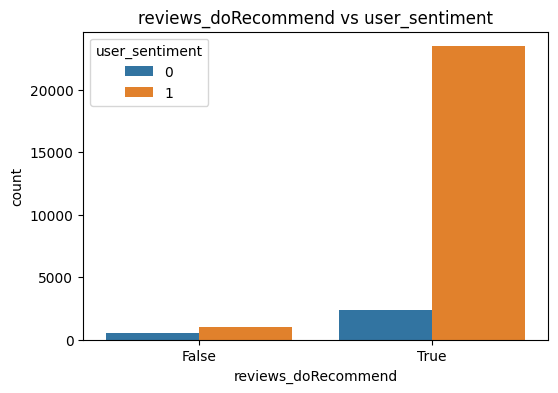

In [28]:
# checking reviews_doRecommend with user_sentiment with annotation
plt.figure(figsize=(6,4))
sns.countplot(reviews_df, x='reviews_doRecommend', hue='user_sentiment')
plt.title('reviews_doRecommend vs user_sentiment')
plt.show()

In [29]:
# Drop column reviews_doRecommend as it is redundant with user_sentiment

reviews_df = reviews_df.drop(columns = ['reviews_doRecommend'], axis = 1)

In [30]:
reviews_df.isnull().sum() *100/reviews_df.shape[0]

id                  0.0
brand               0.0
categories          0.0
name                0.0
reviews_rating      0.0
reviews_text        0.0
reviews_title       0.0
reviews_username    0.0
user_sentiment      0.0
dtype: float64

In [31]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29809 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                29809 non-null  object
 1   brand             29809 non-null  object
 2   categories        29809 non-null  object
 3   name              29809 non-null  object
 4   reviews_rating    29809 non-null  int64 
 5   reviews_text      29809 non-null  object
 6   reviews_title     29809 non-null  object
 7   reviews_username  29809 non-null  object
 8   user_sentiment    29809 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 2.3+ MB


##4. Exploratory Data Analysis

Text(0.5, 1.0, 'Distribution of User Sentiment')

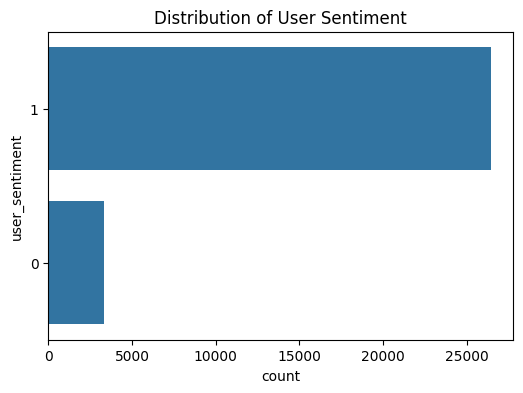

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(data=reviews_df, y='user_sentiment', order=reviews_df['user_sentiment'].value_counts().index)
plt.title('Distribution of User Sentiment')

we can see there is a class imbalance which will get handled later

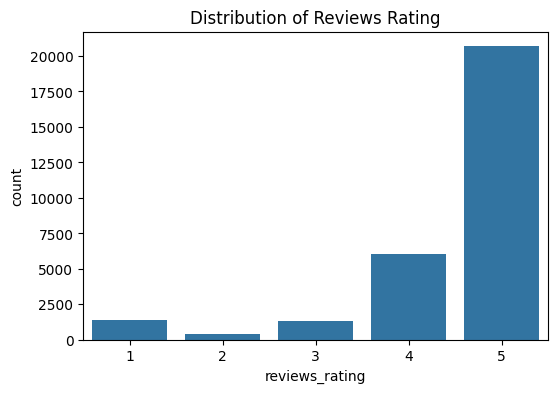

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(data=reviews_df, x='reviews_rating', order=sorted(reviews_df['reviews_rating'].unique()))
plt.title('Distribution of Reviews Rating')
plt.show()

 there is a class imbalance as most of the ratings are 5

Value Counts for 'reviews_username' (Top 10):
reviews_username
Anonymous            62
mike                 41
byamazon customer    41
chris                31
sandy                15
rick                 15
tony                 14
john                 14
dave                 14
jojo                 13
Name: count, dtype: int64


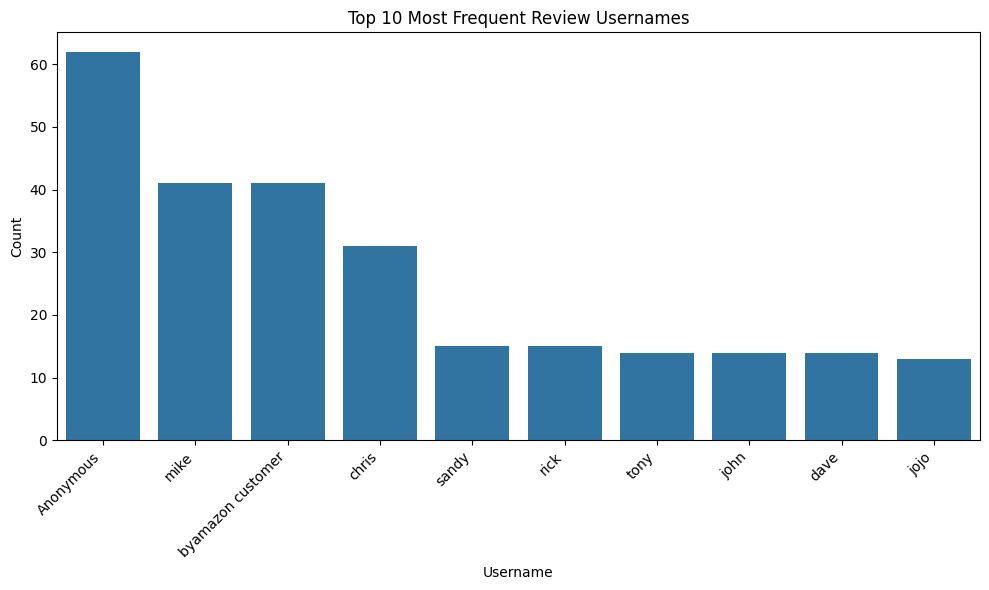

In [34]:
print("Value Counts for 'reviews_username' (Top 10):")
top_10_usernames = reviews_df['reviews_username'].value_counts().head(10)
print(top_10_usernames)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_usernames.index, y=top_10_usernames.values)
plt.title('Top 10 Most Frequent Review Usernames')
plt.xlabel('Username')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Top 5 Brands with Positive Reviews')

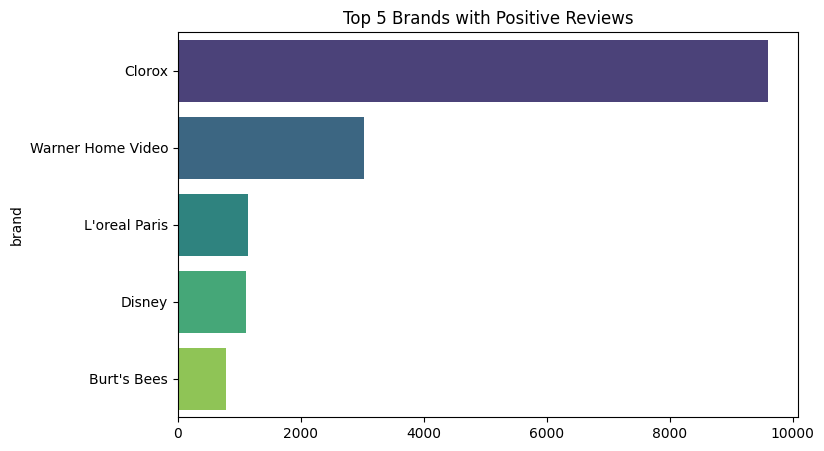

In [35]:
# plot top 5 brands with positive reviews

top_5_positive_brands = reviews_df[reviews_df['user_sentiment'] == 1]['brand'].value_counts().head(5)
plt.figure(figsize=(8,5))
sns.barplot(x=top_5_positive_brands.values, y=top_5_positive_brands.index, palette='viridis')
plt.title('Top 5 Brands with Positive Reviews')

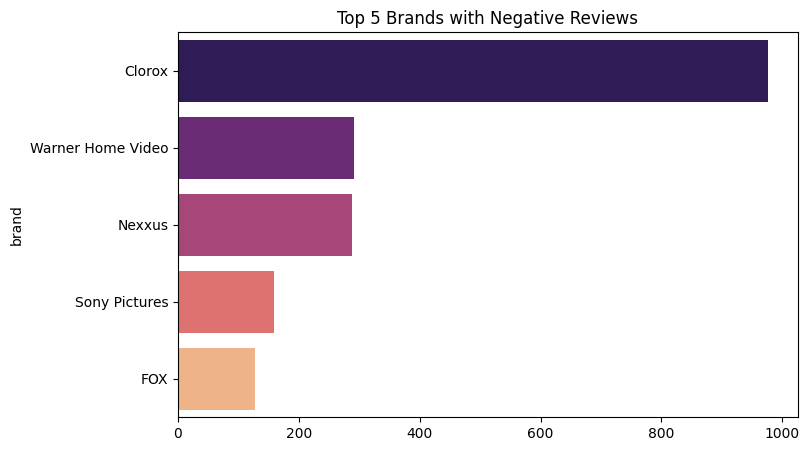

In [36]:
top_5_negative_brands = reviews_df[reviews_df['user_sentiment'] == 0]['brand'].value_counts().head(5)
plt.figure(figsize=(8,5))
sns.barplot(x=top_5_negative_brands.values, y=top_5_negative_brands.index, palette='magma')
plt.title('Top 5 Brands with Negative Reviews')
plt.show()

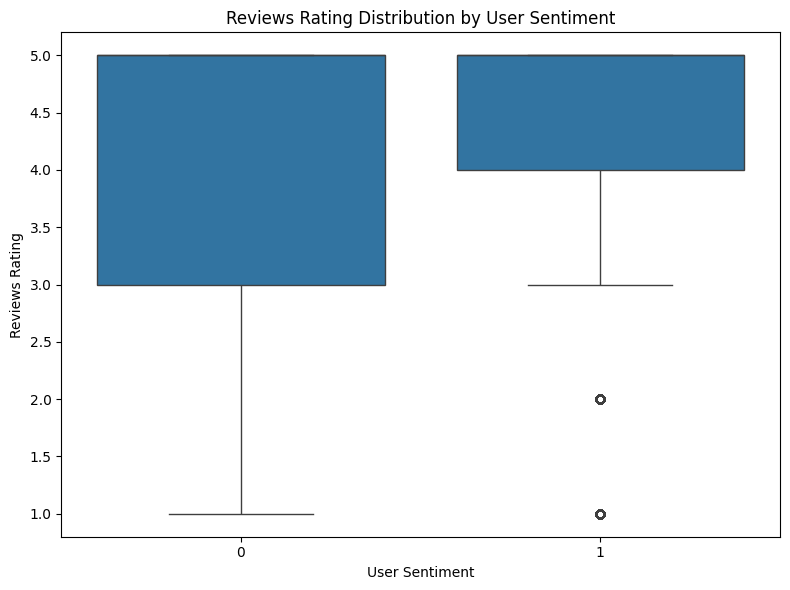

In [37]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='user_sentiment', y='reviews_rating', data=reviews_df)
plt.title('Reviews Rating Distribution by User Sentiment')
plt.xlabel('User Sentiment')
plt.ylabel('Reviews Rating')
plt.tight_layout()
plt.show()

In [38]:
reviews_df['user_sentiment'].value_counts()

user_sentiment
1    26464
0     3345
Name: count, dtype: int64

In [39]:
clean_reviews_df = reviews_df.copy()

# Detecting misclassifications where the user sentiment is Negative but the ratings is greater than 4.

clean_reviews_df[(clean_reviews_df['user_sentiment'] == 0) & (clean_reviews_df['reviews_rating'] >= 4)].groupby('reviews_rating').count().user_sentiment

reviews_rating
4     548
5    1853
Name: user_sentiment, dtype: int64

In [40]:
# Detecting misclassifications where the user sentiment is Positive but the ratings is less than 2.

clean_reviews_df[(clean_reviews_df['user_sentiment'] == 1) & (clean_reviews_df['reviews_rating'] <=2)].groupby('reviews_rating').count().user_sentiment

reviews_rating
1    783
2    274
Name: user_sentiment, dtype: int64

In [41]:
# Updating the misclassified user_sentiment values to align with reviews_rating

clean_reviews_df.loc[(clean_reviews_df['user_sentiment'] == 0) & (clean_reviews_df['reviews_rating'] >= 4), 'user_sentiment'] = 1


In [42]:
# updating misclassified Positive sentiments with ratings less than or equal to 2 to Negative

clean_reviews_df.loc[(clean_reviews_df['user_sentiment'] == 1) & (clean_reviews_df['reviews_rating'] <= 2), 'user_sentiment'] = 0


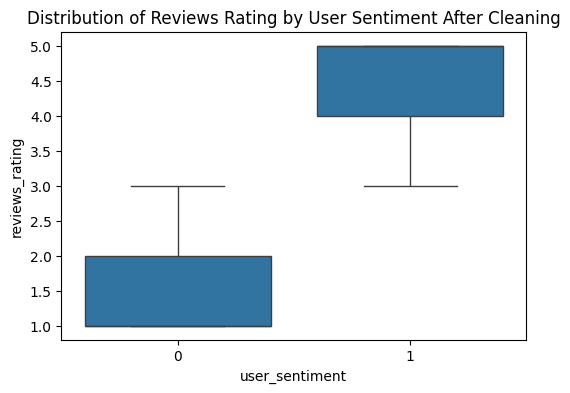

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(data=clean_reviews_df, x='user_sentiment', y='reviews_rating')
plt.title('Distribution of Reviews Rating by User Sentiment After Cleaning')
plt.show()

In [44]:
average_ratings_by_brand = clean_reviews_df.groupby('brand')['reviews_rating'].mean().sort_values(ascending=False)

top_10_brands_by_rating = average_ratings_by_brand.head(10)
bottom_10_brands_by_rating = average_ratings_by_brand.tail(10)

print("Top 10 Brands by Average Rating:\n", top_10_brands_by_rating)
print("\nBottom 10 Brands by Average Rating:\n", bottom_10_brands_by_rating)

Top 10 Brands by Average Rating:
 brand
4C Foods                     5.0
Alberto VO5                  5.0
Carson-Dellosa Publishing    5.0
Biokleen                     5.0
Bodycology                   5.0
Brownline                    5.0
Barielle                     5.0
Fiskars                      5.0
Happy Family                 5.0
Dermalogica                  5.0
Name: reviews_rating, dtype: float64

Bottom 10 Brands by Average Rating:
 brand
Clear Scalp & Hair Therapy    2.835580
D-Con                         2.571429
K-Y                           2.518519
Feit                          2.500000
Toy Story                     2.000000
Nexxus                        1.348770
National Mfg.                 1.000000
Kenroy Home                   1.000000
Udi's                         1.000000
Yosemite Home Decor           1.000000
Name: reviews_rating, dtype: float64


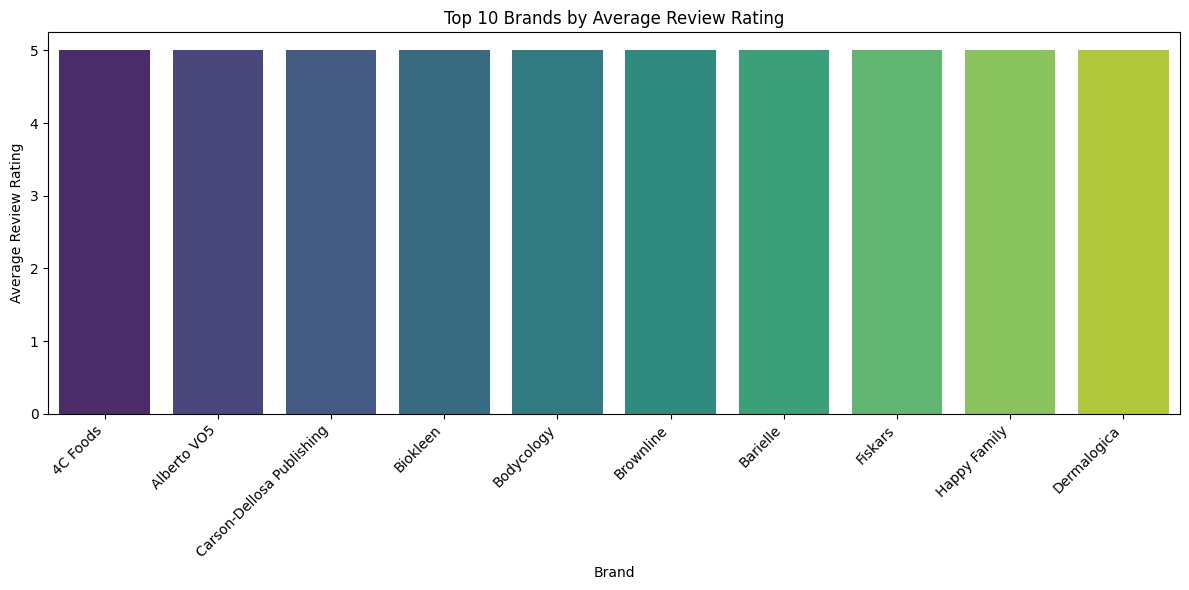

In [45]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_brands_by_rating.index, y=top_10_brands_by_rating.values, hue=top_10_brands_by_rating.index, palette='viridis', legend=False)
plt.title('Top 10 Brands by Average Review Rating')
plt.xlabel('Brand')
plt.ylabel('Average Review Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

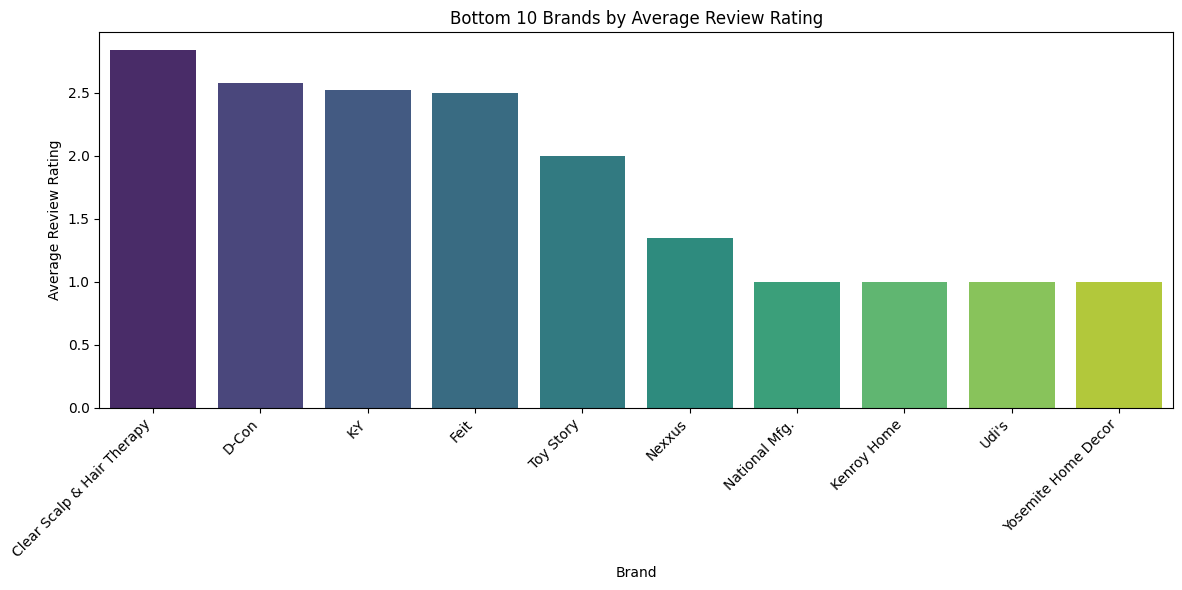

In [46]:
plt.figure(figsize=(12, 6))
sns.barplot(x=bottom_10_brands_by_rating.index, y=bottom_10_brands_by_rating.values, hue=bottom_10_brands_by_rating.index, palette='viridis', legend=False)
plt.title('Bottom 10 Brands by Average Review Rating')
plt.xlabel('Brand')
plt.ylabel('Average Review Rating')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##5. Text Pre Processing

In [47]:
# Combining title and review text to capture full context
# Titles often contain key sentiment indicators that complement the main review
clean_reviews_df["reviews_combined"] = clean_reviews_df["reviews_text"] + " " + clean_reviews_df["reviews_title"]

In [48]:
clean_reviews_df

,id,brand,categories,name,reviews_rating,reviews_text,reviews_title,reviews_username,user_sentiment,reviews_combined
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",Pink Friday: Roman Reloaded Re-Up (w/dvd),5,i love this album. it's very good. more to the...,Just Awesome,joshua,1,i love this album. it's very good. more to the...
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg Organic Cinnamon Toast Rice Cakes,5,Good flavor. This review was collected as part...,Good,dorothy w,1,Good flavor. This review was collected as part...
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",Lundberg Organic Cinnamon Toast Rice Cakes,5,Good flavor.,Good,dorothy w,1,Good flavor. Good
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y Love Sensuality Pleasure Gel,1,I read through the reviews on here before look...,Disappointed,rebecca,0,I read through the reviews on here before look...
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",K-Y Love Sensuality Pleasure Gel,1,My husband bought this gel for us. The gel cau...,Irritation,walker557,0,My husband bought this gel for us. The gel cau...
...,...,...,...,...,...,...,...,...,...,...
29995,AVpfW8y_LJeJML437ySW,L'oreal Paris,"Beauty,Hair Care,Shampoo & Conditioner,Holiday...",L'or233al Paris Elvive Extraordinary Clay Reba...,5,I got this conditioner with Influenster to try...,Softness!!,laurasnchz,1,I got this conditioner with Influenster to try...
29996,AVpfW8y_LJeJML437ySW,L'oreal Paris,"Beauty,Hair Care,Shampoo & Conditioner,Holiday...",L'or233al Paris Elvive Extraordinary Clay Reba...,5,"I love it , I received this for review purpose...",I love it,scarlepadilla,1,"I love it , I received this for review purpose..."
29997,AVpfW8y_LJeJML437ySW,L'oreal Paris,"Beauty,Hair Care,Shampoo & Conditioner,Holiday...",L'or233al Paris Elvive Extraordinary Clay Reba...,5,First of all I love the smell of this product....,Hair is so smooth after use,liviasuexo,1,First of all I love the smell of this product....
29998,AVpfW8y_LJeJML437ySW,L'oreal Paris,"Beauty,Hair Care,Shampoo & Conditioner,Holiday...",L'or233al Paris Elvive Extraordinary Clay Reba...,5,I received this through Influenster and will n...,Perfect for my oily hair!,ktreed95,1,I received this through Influenster and will n...


In [49]:
# Drop columns reviews_title and reviews_text as we have combined them

clean_reviews_df = clean_reviews_df.drop(columns = ['reviews_title','reviews_text'], axis=1)

In [50]:
clean_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29809 entries, 0 to 29999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                29809 non-null  object
 1   brand             29809 non-null  object
 2   categories        29809 non-null  object
 3   name              29809 non-null  object
 4   reviews_rating    29809 non-null  int64 
 5   reviews_username  29809 non-null  object
 6   user_sentiment    29809 non-null  int64 
 7   reviews_combined  29809 non-null  object
dtypes: int64(2), object(6)
memory usage: 2.0+ MB


In [51]:
# reset index and save csv file
clean_reviews_df = clean_reviews_df.reset_index(drop=True)
clean_reviews_df.to_csv("data/reviews_cleaned.csv", index=False)



In [52]:
newReview_df = pd.read_csv("data/reviews_cleaned.csv")

In [53]:
newReview_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29809 entries, 0 to 29808
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                29809 non-null  object
 1   brand             29809 non-null  object
 2   categories        29809 non-null  object
 3   name              29809 non-null  object
 4   reviews_rating    29809 non-null  int64 
 5   reviews_username  29809 non-null  object
 6   user_sentiment    29809 non-null  int64 
 7   reviews_combined  29809 non-null  object
dtypes: int64(2), object(6)
memory usage: 1.8+ MB


In [54]:
#text pre processing, we will using id, name, reviews_combined and user_sentiment columns
newReview_df = newReview_df[['id', 'name', 'reviews_combined', 'user_sentiment']]

In [55]:
newReview_df.head(1)

,id,name,reviews_combined,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Pink Friday: Roman Reloaded Re-Up (w/dvd),i love this album. it's very good. more to the...,1


In [56]:
# Text cleaning function to standardize review text before feature extraction
def text_clean(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [57]:
newReview_df['reviews_combined'][0]

"i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy. Just Awesome"

In [58]:
newReview_df['reviews_combined'] = newReview_df['reviews_combined'].apply(text_clean)

# inspect the cleaned reviews
newReview_df.head()

,id,name,reviews_combined,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Pink Friday: Roman Reloaded Re-Up (w/dvd),i love this album its very good more to the hi...,1
1,AV14LG0R-jtxr-f38QfS,Lundberg Organic Cinnamon Toast Rice Cakes,good flavor this review was collected as part ...,1
2,AV14LG0R-jtxr-f38QfS,Lundberg Organic Cinnamon Toast Rice Cakes,good flavor good,1
3,AV16khLE-jtxr-f38VFn,K-Y Love Sensuality Pleasure Gel,i read through the reviews on here before look...,0
4,AV16khLE-jtxr-f38VFn,K-Y Love Sensuality Pleasure Gel,my husband bought this gel for us the gel caus...,0


In [59]:
newReview_df['reviews_combined'][0]

'i love this album its very good more to the hip hop side than her current pop sound so hype i listen to this everyday at the gym i give it 5star rating all the way her metaphors are just crazy just awesome'

In [60]:
# stopwords

stopwords = set(stopwords.words('english'))

print(stopwords)

{"shouldn't", 'should', 'my', 'mustn', 're', 'ain', 'all', 'can', 'isn', 'couldn', "should've", 'wouldn', 'was', 'not', 'down', "they've", "i'd", 'against', "he'll", 'am', 'on', 's', 'were', 'yourselves', 'do', 'during', 'their', 'because', "he'd", 'then', "hadn't", 'he', "we're", "weren't", 'what', 'her', "i've", 'we', 'are', "it's", 'into', 'ma', 'each', 't', 'being', "hasn't", "wasn't", 'mightn', "it'd", 'again', "they'll", 'she', "they'd", 'been', 'to', 'few', 'has', 'of', 'ourselves', 'having', 'shan', 'no', 'for', "they're", "you'd", 'your', 'm', 'd', 'while', 'doesn', 'don', "isn't", 'how', 'him', 'here', "you've", "she's", 'does', 'than', 'out', 'as', 'such', 'further', 'who', 'that', 'did', 'now', "shan't", 'nor', 'both', 'these', 'after', 'wasn', 'its', "she'll", 'those', "we'd", 'won', "wouldn't", 'our', 'over', "mightn't", 'any', 'up', 'or', 'where', 'had', 'o', 'i', "haven't", 'only', 'yours', "i'll", 'themselves', 'from', 'by', 'very', 'between', 'haven', 'shouldn', 'it',

In [61]:
# remove stopwords from reviews_combined column
def remove_stopwords(text):
  tokens = word_tokenize(text)
  filtered_tokens = [word for word in tokens if word.lower() not in stopwords]
  return ' '.join(filtered_tokens)

In [62]:
newReview_df['reviews_combined'] = newReview_df['reviews_combined'].apply(remove_stopwords)


In [63]:
newReview_df.head(1)

,id,name,reviews_combined,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Pink Friday: Roman Reloaded Re-Up (w/dvd),love album good hip hop side current pop sound...,1


In [64]:
# lemmatization of reviews_combined column

def lemmatize_reviews(text):
  doc = nlp(text)
  lemmas = ' '.join(token.lemma_ for token in doc)
  return lemmas

In [65]:
newReview_df['reviews_lemmatized'] = newReview_df['reviews_combined'].apply(lemmatize_reviews)
newReview_df.head(5)

,id,name,reviews_combined,user_sentiment,reviews_lemmatized
0,AV13O1A8GV-KLJ3akUyj,Pink Friday: Roman Reloaded Re-Up (w/dvd),love album good hip hop side current pop sound...,1,love album good hip hop side current pop sound...
1,AV14LG0R-jtxr-f38QfS,Lundberg Organic Cinnamon Toast Rice Cakes,good flavor review collected part promotion good,1,good flavor review collect part promotion good
2,AV14LG0R-jtxr-f38QfS,Lundberg Organic Cinnamon Toast Rice Cakes,good flavor good,1,good flavor good
3,AV16khLE-jtxr-f38VFn,K-Y Love Sensuality Pleasure Gel,read reviews looking buying one couples lubric...,0,read review look buy one couple lubricant ulti...
4,AV16khLE-jtxr-f38VFn,K-Y Love Sensuality Pleasure Gel,husband bought gel us gel caused irritation fe...,0,husband buy gel us gel cause irritation feel l...


In [66]:
Sentiment_df  = newReview_df[['id','name','reviews_lemmatized','user_sentiment']]
newReview_df.to_csv("data/sentiment_df.csv", index=False)



In [67]:
sentiment_df = pd.read_csv("data/sentiment_df.csv")

In [68]:
sentiment_df.isna().sum()

id                    0
name                  0
reviews_combined      0
user_sentiment        0
reviews_lemmatized    0
dtype: int64

##6. Feature Extraction

TF-IDF transforms textual data into numerical features by assigning lower weights to commonly occurring words and higher weights to more informative, sentiment-relevant terms. This improves the model’s ability to focus on meaningful information and enhances overall performance.

It measures how rare a word is across the entire collection of documents, allowing the model to emphasize distinctive features while reducing the impact of frequently occurring but less informative words.

max_df = 0.95: Excludes words that appear in more than 95% of the documents, as such highly frequent words contribute little to distinguishing between texts.

min_df = 5: Retains only those words that occur in at least five documents, eliminating extremely rare terms that may add noise and reduce generalization.

In [69]:
tfidf_vectorizer = TfidfVectorizer(
     max_df = 0.95,
     min_df = 5,
     stop_words = 'english',
     ngram_range = (1,2) # use unigrams and bigrams
 )

# applying vectorizer on lemmatized reviews

X_features = tfidf_vectorizer.fit_transform(sentiment_df['reviews_lemmatized'])

# target variable

y_labels = sentiment_df['user_sentiment']

In [70]:
tfidf_vectorizer

TfidfVectorizer(max_df=0.95, min_df=5, ngram_range=(1, 2), stop_words='english')

In [71]:
# get the feature names

feature_names = tfidf_vectorizer.get_feature_names_out()

# compute average tf-idf scores for each feature

avg_tfidf_scores = np.asarray(X_features.mean(axis=0)).ravel()

# Create a dataframe

tfidf_data = pd.DataFrame({'Feature': feature_names, 'Avg TF-IDF Score': avg_tfidf_scores}).sort_values(by='Avg TF-IDF Score', ascending=False)

# inspect the dataframe

tfidf_data.head(10)

,Feature,Avg TF-IDF Score
5810,great,0.039042
9106,movie,0.037681
8299,love,0.034958
10637,product,0.032115
14502,use,0.031222
5491,good,0.027937
15451,wipe,0.027312
11772,review,0.026035
2365,collect,0.025249
10950,promotion,0.025218


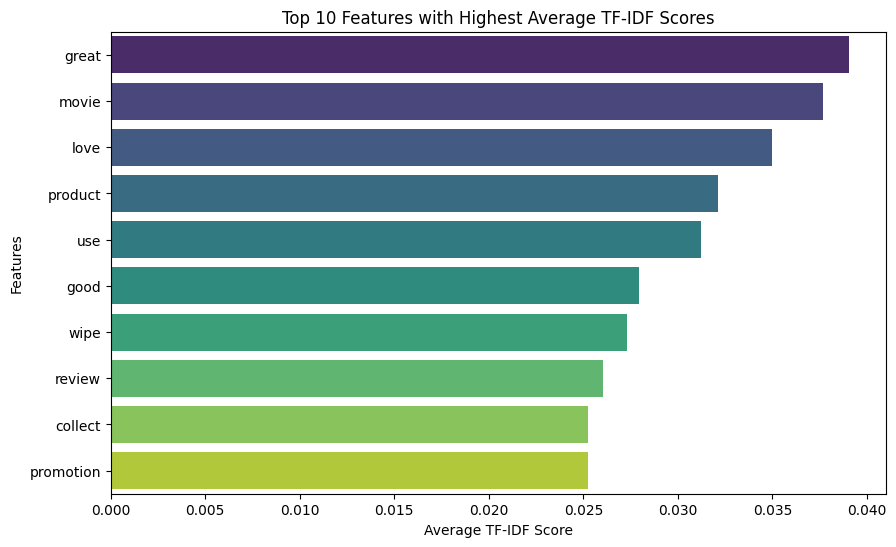

In [72]:
# plotting top 10 features

plt.figure(figsize=(10,6))
sns.barplot(data=tfidf_data.head(10), x='Avg TF-IDF Score', y='Feature', palette='viridis')
plt.title('Top 10 Features with Highest Average TF-IDF Scores')
plt.xlabel('Average TF-IDF Score')
plt.ylabel('Features')
plt.show()

In [73]:
save_pickle_model(tfidf_vectorizer, 'models/', 'tfidf_vectorizer.pkl')

✅ Model saved successfully at: models/tfidf_vectorizer.pkl


In [74]:
df_final = pd.read_csv("data/sentiment_df.csv")

In [75]:
df_final.head(1)

,id,name,reviews_combined,user_sentiment,reviews_lemmatized
0,AV13O1A8GV-KLJ3akUyj,Pink Friday: Roman Reloaded Re-Up (w/dvd),love album good hip hop side current pop sound...,1,love album good hip hop side current pop sound...


In [76]:
df_final.head()

,id,name,reviews_combined,user_sentiment,reviews_lemmatized
0,AV13O1A8GV-KLJ3akUyj,Pink Friday: Roman Reloaded Re-Up (w/dvd),love album good hip hop side current pop sound...,1,love album good hip hop side current pop sound...
1,AV14LG0R-jtxr-f38QfS,Lundberg Organic Cinnamon Toast Rice Cakes,good flavor review collected part promotion good,1,good flavor review collect part promotion good
2,AV14LG0R-jtxr-f38QfS,Lundberg Organic Cinnamon Toast Rice Cakes,good flavor good,1,good flavor good
3,AV16khLE-jtxr-f38VFn,K-Y Love Sensuality Pleasure Gel,read reviews looking buying one couples lubric...,0,read review look buy one couple lubricant ulti...
4,AV16khLE-jtxr-f38VFn,K-Y Love Sensuality Pleasure Gel,husband bought gel us gel caused irritation fe...,0,husband buy gel us gel cause irritation feel l...


In [77]:
X_features = tfidf_vectorizer.fit_transform(df_final['reviews_lemmatized'])

y_labels = df_final['user_sentiment']

## Train - Test Split

In [78]:
# splitting data into train and test datasets for model building

X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels, random_state = 42, test_size = 0.3)

print("X_train Shape ", X_train.shape)
print("X_test Shape ", X_test.shape)
print("y_train Shape ", y_train.shape)
print("y_test Shape ", y_test.shape)

X_train Shape  (20866, 16003)
X_test Shape  (8943, 16003)
y_train Shape  (20866,)
y_test Shape  (8943,)


In [79]:
print(df_final['user_sentiment'].value_counts(normalize= True))

user_sentiment
1    0.932873
0    0.067127
Name: proportion, dtype: float64


In [80]:
def evaluate_model(model, X_train, y_train, X_test, y_test):

    # ================= PREDICTIONS =================
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Probabilities (if available)
    if hasattr(model, "predict_proba"):
        y_train_prob = model.predict_proba(X_train)[:, 1]
        y_test_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_train_prob = None
        y_test_prob = None

    # Ensure binary numeric labels
    y_train_bin = pd.Series(y_train).astype(int)
    y_test_bin = pd.Series(y_test).astype(int)

    # ===================== TRAIN =====================
    print("\n================= TRAIN METRICS =================\n")
    print(f"Accuracy           : {accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Balanced Accuracy  : {balanced_accuracy_score(y_train, y_train_pred):.4f}")
    print(f"Precision          : {precision_score(y_train, y_train_pred, zero_division=0):.4f}")
    print(f"Recall             : {recall_score(y_train, y_train_pred, zero_division=0):.4f}")
    print(f"F1 Score           : {f1_score(y_train, y_train_pred, zero_division=0):.4f}")

    if y_train_prob is not None:
        print(f"ROC AUC            : {roc_auc_score(y_train_bin, y_train_prob):.4f}")

    print("\nCLASSIFICATION REPORT")
    print(classification_report(y_train, y_train_pred, zero_division=0))

    print("\n" + "="*60)

    # ===================== TEST =====================
    print("\n================= TEST METRICS =================\n")
    print(f"Accuracy           : {accuracy_score(y_test, y_test_pred):.4f}")
    print(f"Balanced Accuracy  : {balanced_accuracy_score(y_test, y_test_pred):.4f}")
    print(f"Precision          : {precision_score(y_test, y_test_pred, zero_division=0):.4f}")
    print(f"Recall             : {recall_score(y_test, y_test_pred, zero_division=0):.4f}")
    print(f"F1 Score           : {f1_score(y_test, y_test_pred, zero_division=0):.4f}")

    if y_test_prob is not None:
        print(f"ROC AUC            : {roc_auc_score(y_test_bin, y_test_prob):.4f}")

    print("\nCLASSIFICATION REPORT")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    # ================= CONFUSION MATRICES =================
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_test = confusion_matrix(y_test, y_test_pred)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    for ax, cm, title in zip(
        [ax1, ax2],
        [cm_train, cm_test],
        ["Train Confusion Matrix", "Test Confusion Matrix"]
    ):
        ax.imshow(cm, cmap="Blues")
        ax.set_title(title)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

    # ================= ROC CURVE =================
    if y_train_prob is not None:
        fpr_train, tpr_train, _ = roc_curve(y_train_bin, y_train_prob)
        fpr_test, tpr_test, _ = roc_curve(y_test_bin, y_test_prob)

        plt.figure(figsize=(7, 5))
        plt.plot(fpr_train, tpr_train, label="Train ROC")
        plt.plot(fpr_test, tpr_test, label="Test ROC")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend()
        plt.show()



================= TRAIN METRICS =================

Accuracy           : 0.9657
Balanced Accuracy  : 0.9760
Precision          : 0.9991
Recall             : 0.9641
F1 Score           : 0.9813
ROC AUC            : 0.9965

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.66      0.99      0.79      1400
           1       1.00      0.96      0.98     19466

    accuracy                           0.97     20866
   macro avg       0.83      0.98      0.89     20866
weighted avg       0.98      0.97      0.97     20866



================= TEST METRICS =================

Accuracy           : 0.9450
Balanced Accuracy  : 0.8871
Precision          : 0.9866
Recall             : 0.9540
F1 Score           : 0.9700
ROC AUC            : 0.9639

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.56      0.82      0.67       601
           1       0.99      0.95      0.97      8342

    accuracy           

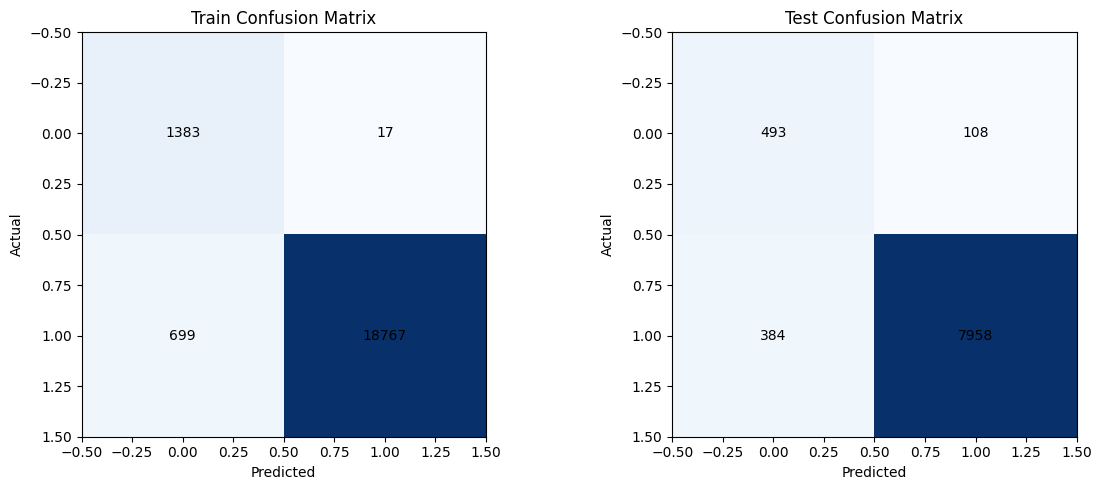

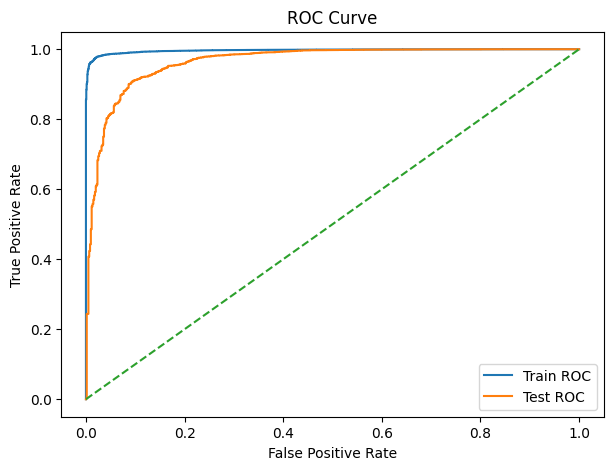

In [81]:
logreg = LogisticRegression(
    class_weight = 'balanced',   # used for class imbalance
    random_state = 42,
    max_iter = 1000,
    solver = 'lbfgs'
)

# train the model
logreg.fit(X_train, y_train)

# evaluate performance
evaluate_model(logreg, X_train, y_train, X_test, y_test)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Params: {'C': np.float64(15.702970884055382), 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

================= TRAIN METRICS =================

Accuracy           : 0.9959
Balanced Accuracy  : 0.9978
Precision          : 1.0000
Recall             : 0.9956
F1 Score           : 0.9978
ROC AUC            : 0.9999

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1400
           1       1.00      1.00      1.00     19466

    accuracy                           1.00     20866
   macro avg       0.97      1.00      0.98     20866
weighted avg       1.00      1.00      1.00     20866



================= TEST METRICS =================

Accuracy           : 0.9644
Balanced Accuracy  : 0.8736
Precision          : 0.9833
Recall             : 0.9785
F1 Score           : 0.9809
ROC AUC            : 0.9607

CLASSIFICATION REPORT
        

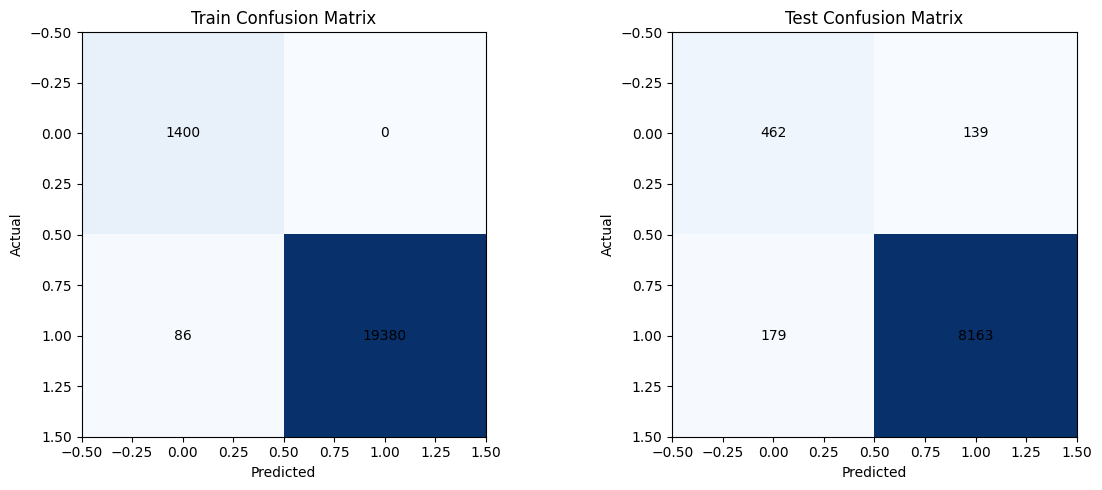

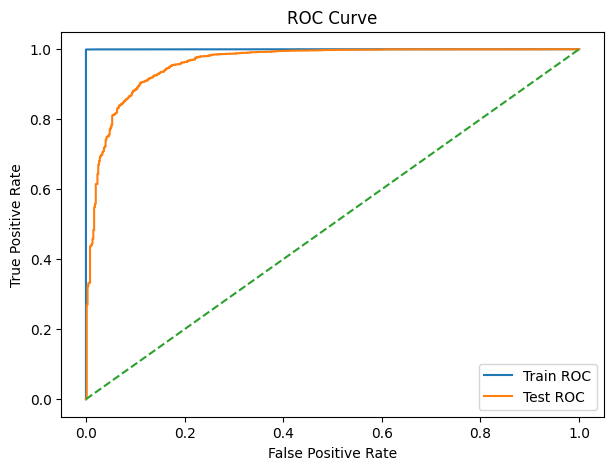

In [82]:
param_grid = {
    'C': loguniform(0.1, 100),
    'penalty': ['l2'],
    'solver': ['liblinear'],
    'class_weight': ['balanced']
}

skfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

base_logreg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

random_search = RandomizedSearchCV(
    estimator=base_logreg,
    param_distributions=param_grid,
    n_iter=5,                      # increase iterations
    scoring='f1_macro',
    cv=skfold,
    n_jobs=-1,                      # use all cores
    verbose=1,
    random_state=42,
    refit=True
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)

best_logreg = random_search.best_estimator_

evaluate_model(best_logreg, X_train, y_train, X_test, y_test)


# Hyperparameter Tuning Summary

Hyperparameter tuning was performed using **RandomizedSearchCV** with:

- 5-fold Stratified Cross-Validation
- F1-macro scoring (to properly handle class imbalance)

---

## Best Parameters Obtained

- **C:** 15.70  
- **Penalty:** L2  
- **Solver:** liblinear  
- **class_weight:** balanced  

---

# Performance Comparison (Test Data)

## Before Tuning

- **Accuracy:** 94.50%  
- **Balanced Accuracy:** 88.71%  
- **Minority Precision (Class 0):** 0.56  
- **Minority Recall (Class 0):** 0.82  
- **Minority F1 Score:** 0.67  
- **ROC-AUC:** 0.9639  

---

## After Tuning

- **Accuracy:** 96.44%  
- **Balanced Accuracy:** 87.36%  
- **Minority Precision (Class 0):** 0.72  
- **Minority Recall (Class 0):** 0.77  
- **Minority F1 Score:** 0.74  
- **ROC-AUC:** 0.9607  

---

# Key Improvements

- Significant improvement in minority class precision (0.56 → 0.72)  
- Improved minority F1 score (0.67 → 0.74)  
- Overall accuracy increased (94.50% → 96.44%)  
- Better precision-recall tradeoff for minority class  
- Slight drop in Balanced Accuracy and ROC-AUC  
- Noticeable increase in training performance (99.59%) indicating mild overfitting  

---

# Important Observation

After tuning:

- The model became more confident  
- Training performance became almost perfect (ROC-AUC ≈ 1.0)  
- Test ROC-AUC slightly decreased  
- Minority recall slightly decreased (0.82 → 0.77)  
- Minority precision improved significantly 

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    8.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   17.4s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.5s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished



================= TRAIN METRICS =================

Accuracy           : 0.9999
Balanced Accuracy  : 0.9999
Precision          : 1.0000
Recall             : 0.9998
F1 Score           : 0.9999
ROC AUC            : 1.0000

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1400
           1       1.00      1.00      1.00     19466

    accuracy                           1.00     20866
   macro avg       1.00      1.00      1.00     20866
weighted avg       1.00      1.00      1.00     20866



================= TEST METRICS =================

Accuracy           : 0.9657
Balanced Accuracy  : 0.7508
Precision          : 0.9654
Recall             : 0.9990
F1 Score           : 0.9819
ROC AUC            : 0.9539

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.97      0.50      0.66       601
           1       0.97      1.00      0.98      8342

    accuracy           

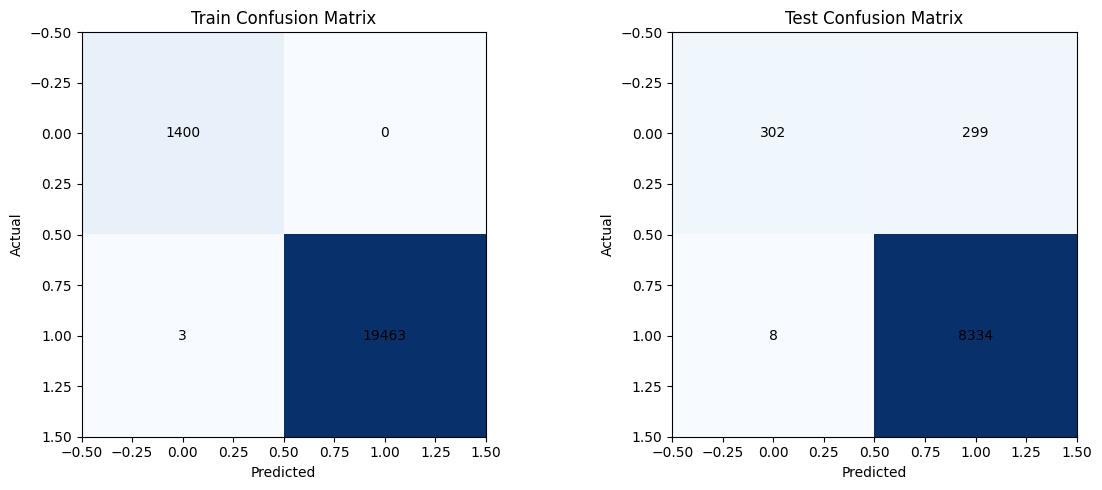

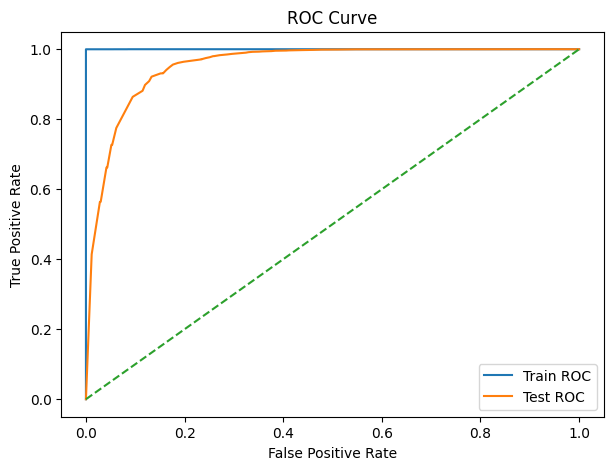

In [83]:
# building random forest model without fine tuning

rf_clf = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
    class_weight = 'balanced',
    verbose = 1,
    n_jobs = 1
)

# Train the model
rf_clf.fit(X_train, y_train)

# Evaluate the model
evaluate_model(rf_clf, X_train, y_train, X_test, y_test)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Params
 {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}

================= TRAIN METRICS =================

Accuracy           : 0.9676
Balanced Accuracy  : 0.9011
Precision          : 0.9872
Recall             : 0.9779
F1 Score           : 0.9825
ROC AUC            : 0.9795

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.73      0.82      0.77      1400
           1       0.99      0.98      0.98     19466

    accuracy                           0.97     20866
   macro avg       0.86      0.90      0.88     20866
weighted avg       0.97      0.97      0.97     20866



================= TEST METRICS =================

Accuracy           : 0.9458
Balanced Accuracy  : 0.8258
Precision          : 0.9772
Recall             : 0.9644
F1 Score           : 0.9707
ROC AUC            : 0.9382

CLASSIFICATION REPORT

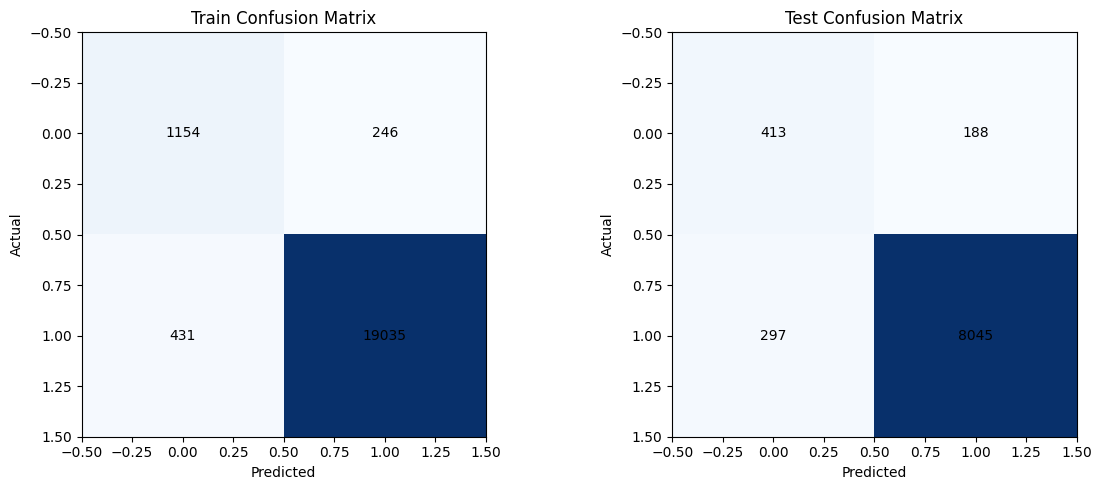

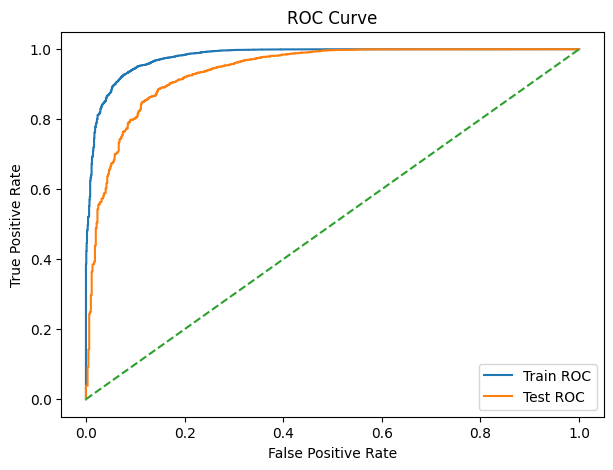

In [84]:
# Hyperparameter tuning for random forest

param_grid = {
    'n_estimators': [100,200],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced'],
    'max_features': ['sqrt']
}

skfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

base_rf = RandomForestClassifier(random_state=42, n_jobs=1)

# randomized search
random_search = RandomizedSearchCV(
    estimator = base_rf,
    param_distributions = param_grid,
    n_iter = 10,
    scoring = 'f1_macro',
    cv = skfold,
    n_jobs = 1,
    verbose = 1,
    random_state = 42,
    refit = True,

)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_
print("Best Params\n",random_search.best_params_)

evaluate_model(best_rf, X_train, y_train, X_test, y_test)

# Random Forest Performance Analysis

---

# Without Hyperparameter Tuning

## Training Performance

- **Training Accuracy:** 99.99%  
- **Training Balanced Accuracy:** 99.99%  
- **Training ROC-AUC:** 1.00  

The model achieved almost perfect training performance, indicating extreme overfitting.

---

## Test Performance

- **Test Accuracy:** 96.57%  
- **Test Balanced Accuracy:** 75.08%  
- **Test ROC-AUC:** 0.9539  

### Minority Class (Class 0)

- **Precision:** 0.97  
- **Recall:** 0.50  
- **F1 Score:** 0.66  

---

## Interpretation

- Model severely overfitted  
- Memorized training data (≈100% accuracy)  
- On test data, it predicted the majority class almost everywhere  
- Missed 50% of minority samples  
- High overall accuracy was misleading due to class imbalance  
- Poor balanced accuracy (75%)  

---

# After Hyperparameter Tuning

## Best Parameters

- **max_depth:** 20  
- **n_estimators:** 100  
- **min_samples_leaf:** 1  
- **class_weight:** 'balanced'  
- **max_features:** 'sqrt'  

---

## Training Performance

- **Training Accuracy:** 96.76%  
- **Training Balanced Accuracy:** 90.11%  
- **Training ROC-AUC:** 0.9795  

Training performance dropped from ~100% → 96%, which is a good sign (overfitting reduced).

---

## Test Performance

- **Test Accuracy:** 94.58%  
- **Test Balanced Accuracy:** 82.58%  
- **Test ROC-AUC:** 0.9382  

### Minority Class (Class 0)

- **Precision:** 0.58  
- **Recall:** 0.69  
- **F1 Score:** 0.63  

---

# Improvements After Tuning

- Overfitting significantly reduced  
- Balanced Accuracy improved (75% → 82%)  
- Minority Recall improved (50% → 69%)  
- Model became more balanced across classes  

---

# Trade-offs Observed

- Slight drop in overall Accuracy (96.57% → 94.58%)  
- Slight drop in ROC-AUC  


================= TRAIN METRICS =================

Accuracy           : 0.9623
Balanced Accuracy  : 0.7193
Precision          : 0.9612
Recall             : 1.0000
F1 Score           : 0.9802
ROC AUC            : 0.9736

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      0.44      0.61      1400
           1       0.96      1.00      0.98     19466

    accuracy                           0.96     20866
   macro avg       0.98      0.72      0.79     20866
weighted avg       0.96      0.96      0.96     20866



================= TEST METRICS =================

Accuracy           : 0.9572
Balanced Accuracy  : 0.6852
Precision          : 0.9566
Recall             : 0.9994
F1 Score           : 0.9775
ROC AUC            : 0.9462

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.98      0.37      0.54       601
           1       0.96      1.00      0.98      8342

    accuracy           

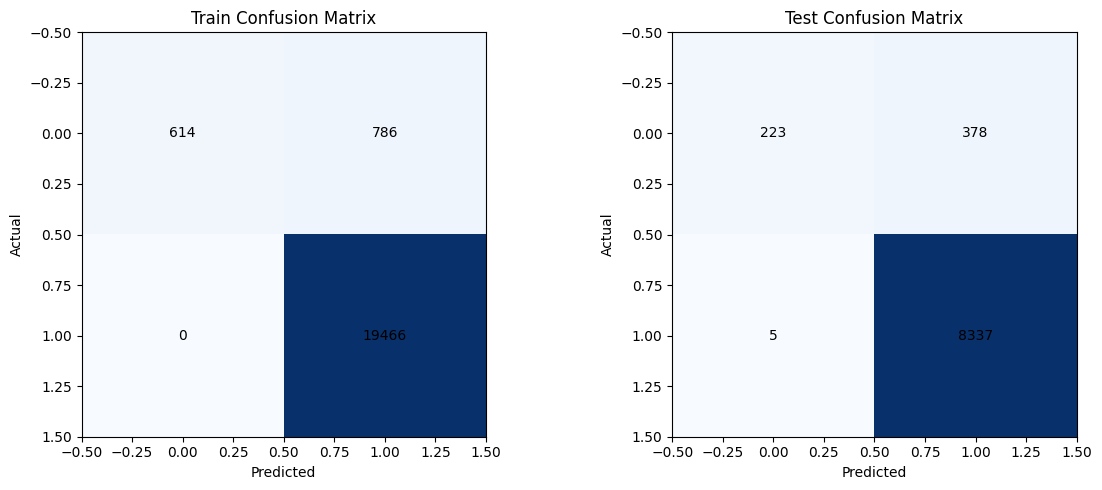

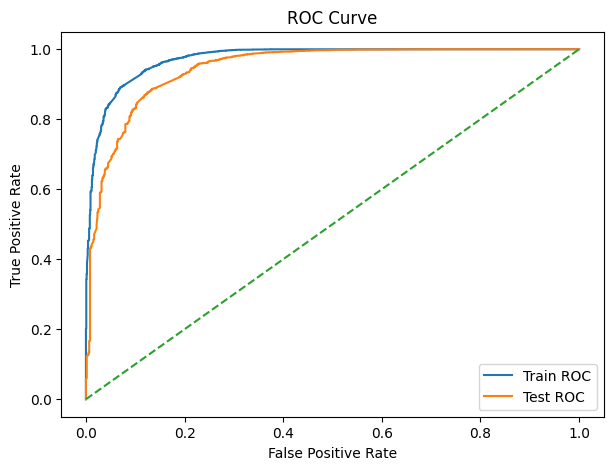

In [85]:
xg_clf = XGBClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 5,
    random_state = 42,
    scale_pos_weight = 14,
    n_jobs = 1,
    verbose = 1,
    eval_metric = 'logloss'
)


# train the model
xg_clf.fit(X_train, y_train)

# evaluate the model
evaluate_model(xg_clf, X_train, y_train, X_test, y_test)

Fitting 3 folds for each of 20 candidates, totalling 60 fits

================= TRAIN METRICS =================

Accuracy           : 0.9734
Balanced Accuracy  : 0.8018
Precision          : 0.9723
Recall             : 1.0000
F1 Score           : 0.9859
ROC AUC            : 0.9903

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      0.60      0.75      1400
           1       0.97      1.00      0.99     19466

    accuracy                           0.97     20866
   macro avg       0.99      0.80      0.87     20866
weighted avg       0.97      0.97      0.97     20866



================= TEST METRICS =================

Accuracy           : 0.9627
Balanced Accuracy  : 0.7283
Precision          : 0.9624
Recall             : 0.9990
F1 Score           : 0.9804
ROC AUC            : 0.9552

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.97      0.46      0.62       601
           1     

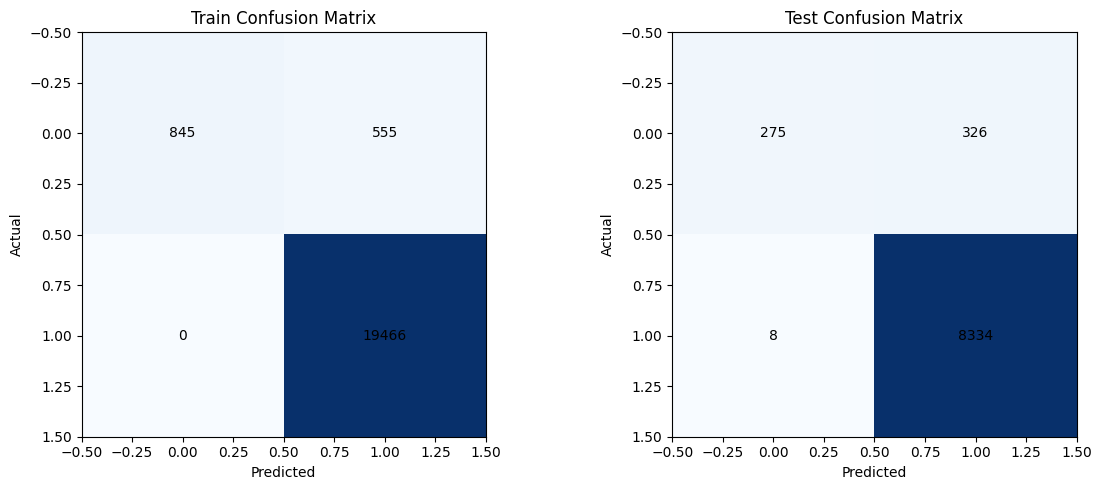

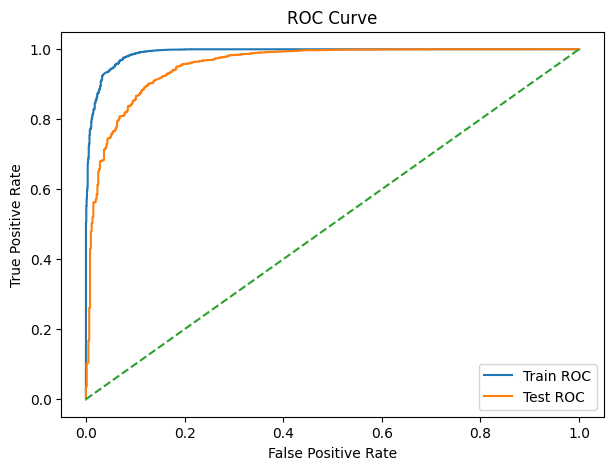

In [86]:
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight = 14,
    random_state=42,
    n_estimators=100
)

param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'min_child_weight': [1, 3],
    'gamma': [0, 0.1],
}


search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=20,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

search.fit(X_train, y_train)

best_xgb = search.best_estimator_
evaluate_model(best_xgb, X_train, y_train, X_test, y_test)

# Model Performance Analysis

---

# Without Hyperparameter Tuning

## Test Performance

- **Accuracy:** 95.72%  
- **Balanced Accuracy:** 68.52%  
- **Minority Class (0) Recall:** 37%  
- **Minority F1 Score:** 0.54  
- **ROC AUC:** 0.9462  

---

## Interpretation

- Model is strongly biased toward the majority class (Class 1)  
- Majority class recall is almost perfect (≈100%)  
- Minority class recall is very low (only 37%)  
- Balanced Accuracy is poor (68%) due to class imbalance  
- High overall accuracy is misleading  
- Model prioritizes predicting the majority class instead of balanced performance  

In short:  
The model predicts almost everything as positive.

---

# After Hyperparameter Tuning

## Test Performance

- **Accuracy:** 96.27%  
- **Balanced Accuracy:** 72.83%  
- **Minority Class (0) Recall:** 46%  
- **Minority F1 Score:** 0.62  
- **ROC AUC:** 0.9552  

---

# Improvements After Tuning

- Balanced Accuracy improved (68.52% → 72.83%)  
- Minority Recall improved (37% → 46%)  
- Minority F1 Score improved (0.54 → 0.62)  
- Slight increase in overall Accuracy  
- ROC AUC improved (0.9462 → 0.9552)  
- Model generalization improved slightly  

---

# Important Observation

Even after tuning:

- Majority class recall remains near perfect  
- Minority class detection is still moderate (46%)  
- Model is still somewhat biased, but improved compared to baseline  

This is a controlled improvement, not a dramatic change.

## Model Evaluation

In [87]:
def get_metrics(model, X, y_true):

    # Convert y_true if needed
    if y_true.dtype == object:
        label_map = {'Negative': 0, 'Positive': 1}
        y_true = pd.Series(y_true).map(label_map).values

    # Predictions
    y_pred = model.predict(X)

    # Convert predictions if needed
    if y_pred.dtype == object:
        label_map = {'Negative': 0, 'Positive': 1}
        y_pred = pd.Series(y_pred).map(label_map).values

    # Probabilities (handle models without predict_proba)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X)[:, 1]
    else:
        y_prob = model.decision_function(X)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_prob)
    }


results = []

models = [
    ("Logistic Regression", "Base", logreg),
    ("Logistic Regression", "Tuned", best_logreg),
    ("Random Forest", "Base", rf_clf),
    ("Random Forest", "Tuned", best_rf),
    ("XGBoost", "Base", xg_clf),
    ("XGBoost", "Tuned", best_xgb),
]

for model_name, model_type, model in models:
    train_metrics = get_metrics(model, X_train, y_train)
    test_metrics = get_metrics(model, X_test, y_test)

    results.append({
        "Model": model_name,
        "Type": model_type,
        "Train Accuracy": train_metrics["Accuracy"],
        "Test Accuracy": test_metrics["Accuracy"],
        "Train F1": train_metrics["F1 Score"],
        "Test F1": test_metrics["F1 Score"],
        "Train Recall": train_metrics["Recall"],
        "Test Recall": test_metrics["Recall"],
        "Train ROC-AUC": train_metrics["ROC AUC"],
        "Test ROC-AUC": test_metrics["ROC AUC"]
    })


results_df = pd.DataFrame(results)
results_df = results_df.set_index(["Model", "Type"])

# Convert to percentage safely
results_df = results_df.applymap(lambda x: round(float(x) * 100, 2))

results_df

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.2s finished


Train Accuracy  Test Accuracy  Train F1  Test F1  \
Model               Type                                                      
Logistic Regression Base            96.57          94.50     98.13    97.00   
                    Tuned           99.59          96.44     99.78    98.09   
Random Forest       Base            99.99          96.57     99.99    98.19   
                    Tuned           96.76          94.58     98.25    97.07   
XGBoost             Base            96.23          95.72     98.02    97.75   
                    Tuned           97.34          96.27     98.59    98.04   

                           Train Recall  Test Recall  Train ROC-AUC  \
Model               Type                                              
Logistic Regression Base          96.41        95.40          99.65   
                    Tuned         99.56        97.85          99.99   
Random Forest       Base          99.98        99.90         100.00   
                    Tuned         97.79        96.44          97.95   
XGBoost             Base         100.00        99.94          97.36   
                    Tuned        100.00        99.90          99.03   

                           Test ROC-AUC  
Model               Type                 
Logistic Regression Base          96.39  
                    Tuned         96.07  
Random Forest       Base          95.39  
                    Tuned         93.82  
XGBoost             Base          94.62  
                    Tuned         95.52

In [88]:
results_df

Train Accuracy  Test Accuracy  Train F1  Test F1  \
Model               Type                                                      
Logistic Regression Base            96.57          94.50     98.13    97.00   
                    Tuned           99.59          96.44     99.78    98.09   
Random Forest       Base            99.99          96.57     99.99    98.19   
                    Tuned           96.76          94.58     98.25    97.07   
XGBoost             Base            96.23          95.72     98.02    97.75   
                    Tuned           97.34          96.27     98.59    98.04   

                           Train Recall  Test Recall  Train ROC-AUC  \
Model               Type                                              
Logistic Regression Base          96.41        95.40          99.65   
                    Tuned         99.56        97.85          99.99   
Random Forest       Base          99.98        99.90         100.00   
                    Tuned         97.79        96.44          97.95   
XGBoost             Base         100.00        99.94          97.36   
                    Tuned        100.00        99.90          99.03   

                           Test ROC-AUC  
Model               Type                 
Logistic Regression Base          96.39  
                    Tuned         96.07  
Random Forest       Base          95.39  
                    Tuned         93.82  
XGBoost             Base          94.62  
                    Tuned         95.52

In [89]:
save_pickle_model(best_logreg, 'models/', 'logreg_model.pkl')
save_pickle_model(best_rf, 'models/','rf_model.pkl')
save_pickle_model(best_xgb, 'models/','xgb_model.pkl')

✅ Model saved successfully at: models/logreg_model.pkl
✅ Model saved successfully at: models/rf_model.pkl
✅ Model saved successfully at: models/xgb_model.pkl


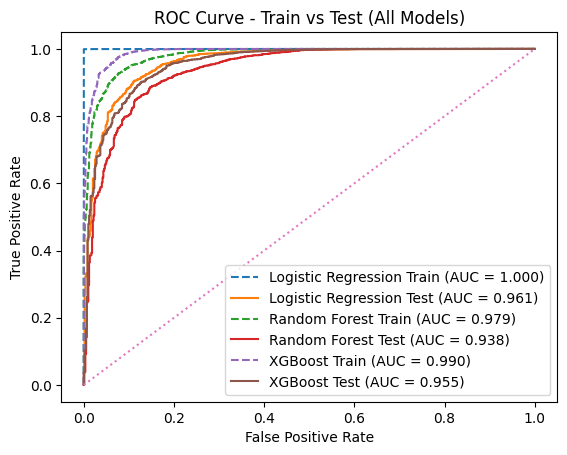

In [90]:

plt.figure()

models = [
    ("Logistic Regression", best_logreg),
    ("Random Forest", best_rf),
    ("XGBoost", best_xgb),
]

for name, model in models:

    # ---- TRAIN ROC ----
    train_probs = model.predict_proba(X_train)[:, 1]
    fpr_train, tpr_train, _ = roc_curve(y_train, train_probs)
    auc_train = roc_auc_score(y_train, train_probs)

    plt.plot(fpr_train, tpr_train, linestyle='--',
             label=f"{name} Train (AUC = {auc_train:.3f})")

    # ---- TEST ROC ----
    test_probs = model.predict_proba(X_test)[:, 1]
    fpr_test, tpr_test, _ = roc_curve(y_test, test_probs)
    auc_test = roc_auc_score(y_test, test_probs)

    plt.plot(fpr_test, tpr_test,
             label=f"{name} Test (AUC = {auc_test:.3f})")

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle=':')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Train vs Test (All Models)")
plt.legend()
plt.show()

## Recommendation System
Memory-based recommendation systems are of two types:

User–User Collaborative Filtering This approach recommends items to a user based on the preferences of other users who are similar to that user.

Item–Item Collaborative Filtering This approach recommends items based on items similar to those the user has liked or interacted with in the past.

In [91]:
recommend_df = pd.read_csv('sample30.csv')
recommend_df = recommend_df[['id','name','reviews_rating','reviews_username']]
recommend_df = recommend_df[~recommend_df.reviews_username.isna()]

In [92]:
recommend_df.isna().sum()

id                  0
name                0
reviews_rating      0
reviews_username    0
dtype: int64

In [93]:
train_data, test_data = train_test_split(recommend_df, test_size=0.3, random_state=42)

print("Train shape: ", train_data.shape)
print("Test shape: ", test_data.shape)

Train shape:  (20955, 4)
Test shape:  (8982, 4)


In [94]:
# pivot the training ratings into matrix format such that rows are usernames and columns are product ids

df_pivot = train_data.pivot_table(
    index='reviews_username',
    columns = 'id',
    values = 'reviews_rating',
).fillna(0)

df_pivot.head(2)

id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,...,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfsQoeilAPnD_xgfx5,AVpfshNsLJeJML43CB8q,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,
00sab00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
01impala,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Creating Dummy Train and Test Dataset

Dummy train will be used to predict the ratings of the products for which the user has not provided any rating. In dummy train, we replace non-rated (null) values with 1 and already rated products with 0, so that predictions are generated only for unseen products.

Dummy test will be used to predict the ratings of the products for which the user has already provided ratings. In dummy test, already rated products are marked as 1 and non-rated products are marked as 0, so that predictions are made only on rated items for evaluation purposes, where actual ratings are available.

In [95]:
dummy_train = train_data.copy()
#products that are not rated by user will be marked as 1.

dummy_train['reviews_rating'] = dummy_train['reviews_rating'].apply(lambda x: 0 if x>=1 else 1)

dummy_train.head(2)

,id,name,reviews_rating,reviews_username
962,AV1YGDqsGV-KLJ3adc-O,Windex Original Glass Cleaner Refill 67.6oz (2...,0,brittney w
10463,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 1...,0,cjshrad


In [96]:
# converting the dummy train dataset into matrix format

dummy_train = dummy_train.pivot_table(
    index='reviews_username',
    columns='id',
    values='reviews_rating'
).fillna(1)

dummy_train.head(2)

id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,...,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfsQoeilAPnD_xgfx5,AVpfshNsLJeJML43CB8q,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,
00sab00,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
01impala,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### User Based Collaborative Filtering
User Similarity Matrix Using Adjusted Cosine

In [97]:
df_pivot = train_data.pivot_table(
    index='reviews_username',
    columns = 'id',
    values = 'reviews_rating'
)

df_pivot.head(3)

id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,...,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfsQoeilAPnD_xgfx5,AVpfshNsLJeJML43CB8q,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,
00sab00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
01impala,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
02dakota,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [98]:
# Normalise the product ratings for each user to be centered around 0 mean.

mean = np.nanmean(df_pivot, axis=1)

# Subtracting the mean

df_subtract = (df_pivot.T - mean).T

In [99]:
#Finding Cosine Similarity
#checking similarity between users based on their product ratings

user_similarity = 1 - pairwise_distances(df_subtract.fillna(0), metric='cosine')

#marking the similarity to 0 wherever there are null values
user_similarity[np.isnan(user_similarity)] = 0

#print user_similarity
print(user_similarity)

print(user_similarity.shape)

[[1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
(18275, 18275)


### User-User Prediction

Using cosine similarity, we aim to predict what a user might like based on the ratings or preferences of other users.

However, we consider only those users who are positively correlated and highly similar, since they share similar preference patterns.

Users with zero or negative similarity are ignored, as they do not contribute meaningful or reliable information for making recommendations.

In [100]:
user_similarity[user_similarity < 0] = 0
user_predicted_ratings = np.dot(user_similarity,df_pivot.fillna(0))
print(user_predicted_ratings)

[[0.         0.         2.5        ... 1.46525748 1.88982237 0.20412415]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [101]:
user_final_rating = np.multiply(user_predicted_ratings,dummy_train)

user_final_rating.head(2)

id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,...,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfsQoeilAPnD_xgfx5,AVpfshNsLJeJML43CB8q,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,
00sab00,0.0,0.0,2.5,3.596262,0.0,0.0,0.0,0.0,2.581989,1.018079,...,1.666667,0.188982,0.0,0.0,0.0,0.0,0.0,1.465257,1.889822,0.204124
01impala,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000


##### Finding the top 20 products a user might like using user-user based recommendation

We have predicted the ratings that a user is likely to give to products they have not rated yet.

Based on the ratings provided by similar users, we recommend the top 20 products that a user is most likely to like.

In [102]:
user_input = '00sab00'
top_20_recommendations = user_final_rating.loc[user_input].sort_values(ascending=False)[0:20]

df_top_20_recommendations = pd.DataFrame({'Product id':top_20_recommendations.index, 'Cosine Similarity Score':top_20_recommendations})

df_top_20_recommendations.reset_index(drop=True, inplace=True)

df_top_20_recommendations

,Product id,Cosine Similarity Score
0,AVpfPaoqLJeJML435Xk9,37.472929
1,AVpfRTh1ilAPnD_xYic2,29.191053
2,AVpf0eb2LJeJML43EVSt,14.259486
3,AVpf3VOfilAPnD_xjpun,12.313738
4,AVpf2tw1ilAPnD_xjflC,11.178377
5,AVpfBrUZilAPnD_xTUly,7.831663
6,AVpfov9TLJeJML43A7B0,6.623441
7,AVpf385g1cnluZ0-s0_t,6.253560
8,AVpfM_ytilAPnD_xXIJb,6.154565
9,AVpfR5m0LJeJML436K3W,5.650706


In [103]:
df_top_20_rec = pd.merge(recommend_df,df_top_20_recommendations,left_on= 'id' ,right_on='Product id',how='inner')[['Product id', 'name', 'Cosine Similarity Score']].drop_duplicates()

df_top_20_rec.reset_index(drop=True, inplace=True)

df_top_20_rec.sort_values(by='Cosine Similarity Score', ascending=False)

,Product id,name,Cosine Similarity Score
16,AVpfPaoqLJeJML435Xk9,Godzilla 3d Includes Digital Copy Ultraviolet ...,37.472929
19,AVpfRTh1ilAPnD_xYic2,Planes: Fire Rescue (2 Discs) (includes Digita...,29.191053
2,AVpf0eb2LJeJML43EVSt,The Resident Evil Collection 5 Discs (blu-Ray),14.259486
6,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 1...,12.313738
4,AVpf2tw1ilAPnD_xjflC,Red (special Edition) (dvdvideo),11.178377
9,AVpfBrUZilAPnD_xTUly,"Coty Airspun Face Powder, Translucent Extra Co...",7.831663
15,AVpfov9TLJeJML43A7B0,Bisquick Original Pancake And Baking Mix - 40oz,6.623441
5,AVpf385g1cnluZ0-s0_t,"Hormel Chili, No Beans",6.253560
11,AVpfM_ytilAPnD_xXIJb,Tostitos Bite Size Tortilla Chips,6.154565
18,AVpfR5m0LJeJML436K3W,Jason Aldean - They Don't Know,5.650706


#### Evaluation User-User

Now, we will evaluate for the product that has already been rated by the user instead of the products that were not rated.

In [104]:
# find common users between train and test

common_users = test_data[test_data.reviews_username.isin(train_data.reviews_username)]
common_users.head(2)

,id,name,reviews_rating,reviews_username
12875,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 1...,5,jessica
21657,AVpfm8yiLJeJML43AYyu,Nexxus Exxtra Gel Style Creation Sculptor,1,romance318


In [105]:
common_users_matrix = common_users.pivot_table(
    index='reviews_username',
    columns='id',
    values='reviews_rating'
)

common_users_matrix.head(2)

id,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YlENIglJLPUi8IHsX,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,AV1YneDPglJLPUi8IJyQ,AV1Ys0kTvKc47QAVgx1C,AV1YtGjdglJLPUi8IOfJ,AV1ZT7GLglJLPUi8IQLI,...,AVpfov9TLJeJML43A7B0,AVpfpM2yilAPnD_xfmDG,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrgjFLJeJML43BvCc,AVpfs0tUilAPnD_xgqN2,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS
reviews_username,,,,,,,,,,,,,,,,,,,,,
1234,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1234567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [106]:
user_similarity_df = pd.DataFrame(user_similarity)

user_similarity_df.head(2)

,0,1,2,3,4,5,6,7,8,9,...,18265,18266,18267,18268,18269,18270,18271,18272,18273,18274
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [107]:
user_similarity_df['user_id'] = df_subtract.index

user_similarity_df.set_index('user_id', inplace=True)

user_similarity_df.head(2)

,0,1,2,3,4,5,6,7,8,9,...,18265,18266,18267,18268,18269,18270,18271,18272,18273,18274
user_id,,,,,,,,,,,,,,,,,,,,,
00sab00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
01impala,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [108]:
list_name = common_users.reviews_username.tolist()

user_similarity_df.columns = df_pivot.index

user_similarity_df1 = user_similarity_df[user_similarity_df.index.isin(list_name)]

print(user_similarity_df1.shape)

user_similarity_df1.head(2)

(1693, 18275)


reviews_username,00sab00,01impala,02dakota,02deuce,0325home,06stidriver,08dallas,09mommy11,1.11E+24,1085,...,zsarah,zsazsa,zubb,zuttle,zwithanx,zxcsdfd,zxjki,zyiah4,zzdiane,zzz1127
user_id,,,,,,,,,,,,,,,,,,,,,
1234,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1234567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [109]:
user_similarity_df2 = user_similarity_df1.T[user_similarity_df1.T.index.isin(list_name)]
user_similarity_df3 = user_similarity_df2.T
user_similarity_df3[user_similarity_df3 < 0] = 0

common_user_predicted_ratings = np.dot(user_similarity_df3,common_users_matrix.fillna(0))

common_user_predicted_ratings

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [110]:
# Creating dummy test dataframe

dummy_test = common_users.copy()

dummy_test['reviews_rating'] = dummy_test['reviews_rating'].apply(lambda x : 1 if x>=1 else 0)

dummy_test = dummy_test.pivot_table(index = 'reviews_username', columns = 'id', values = 'reviews_rating').fillna(0)

dummy_test.head(2)

id,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YlENIglJLPUi8IHsX,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,AV1YneDPglJLPUi8IJyQ,AV1Ys0kTvKc47QAVgx1C,AV1YtGjdglJLPUi8IOfJ,AV1ZT7GLglJLPUi8IQLI,...,AVpfov9TLJeJML43A7B0,AVpfpM2yilAPnD_xfmDG,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrgjFLJeJML43BvCc,AVpfs0tUilAPnD_xgqN2,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS
reviews_username,,,,,,,,,,,,,,,,,,,,,
1234,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1234567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [111]:
common_user_predicted_ratings = np.multiply(common_user_predicted_ratings,dummy_test)

X = common_user_predicted_ratings.copy()
X = X[X>0]

scaler = MinMaxScaler(feature_range=(1,5))

print(scaler.fit(X))

y = scaler.transform(X)

MinMaxScaler(feature_range=(1, 5))


In [112]:
common_df = common_users.pivot_table(
    index='reviews_username',
    columns='id',
    values='reviews_rating')
total_non_nan = np.count_nonzero(~np.isnan(y))
rmse = sqrt(( (common_df - y)**2 ).sum().sum() / total_non_nan)

print(rmse)

2.551419404666111


The obtained RMSE of 2.55 indicates that the predicted ratings deviate from actual ratings by approximately 2.5 points on average. Given the sparsity of the dataset and the use of a baseline user-based collaborative filtering approach, this performance is acceptable for generating top-N recommendations.

### Item based Collaborative Filtering

In item-based collaborative filtering, the rating matrix is transposed so that ratings can be normalized around the mean rating of each product. This helps remove product-specific rating bias before computing item similarity. In contrast, for user-based collaborative filtering, ratings are normalized around the mean rating of each user.

In [113]:
df_pivot = train_data.pivot_table(
    index='reviews_username',
    columns = 'id',
    values = 'reviews_rating'
).T

mean = np.nanmean(df_pivot, axis=1)
df_subtract = (df_pivot.T-mean).T
df_subtract.head(2)

reviews_username,00sab00,01impala,02dakota,02deuce,0325home,06stidriver,08dallas,09mommy11,1.11E+24,1085,...,zsarah,zsazsa,zubb,zuttle,zwithanx,zxcsdfd,zxjki,zyiah4,zzdiane,zzz1127
id,,,,,,,,,,,,,,,,,,,,,
AV13O1A8GV-KLJ3akUyj,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AV14LG0R-jtxr-f38QfS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [114]:
# finding cosine similarity using pairwise distance

cosine_similarity_items = 1 - pairwise_distances(df_subtract.fillna(0), metric='cosine')

cosine_similarity_items[np.isnan(cosine_similarity_items)] = 0
cosine_similarity_items[cosine_similarity_items < 0] = 0

cosine_similarity_items

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [115]:
### Item - Item Prediction
item_predicted_ratings = np.dot(df_pivot.fillna(0).T,cosine_similarity_items)

item_predicted_ratings

array([[0.        , 0.        , 0.        , ..., 0.00603917, 0.06485571,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.0094556 ],
       [0.        , 0.        , 0.        , ..., 0.00781596, 0.10809285,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.00756448]])

In [116]:
item_final_ratings = np.multiply(item_predicted_ratings,dummy_train)

item_final_ratings.head(2)

id,AV13O1A8GV-KLJ3akUyj,AV14LG0R-jtxr-f38QfS,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YIch7GV-KLJ3addeG,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,...,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfsQoeilAPnD_xgfx5,AVpfshNsLJeJML43CB8q,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
reviews_username,,,,,,,,,,,,,,,,,,,,,
00sab00,0.0,0.0,0.0,0.006042,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.020509,0.006039,0.064856,0.0
01impala,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.097645,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0


##### Finding the top 20 Items that a user might like and purchase based on ratings

In [117]:
user_input = '00sab00'
top_20_item_recommendations = item_final_ratings.loc[user_input].sort_values(ascending=False)[0:20]

df_top_20_item_recommendations = pd.DataFrame({'Product id':top_20_item_recommendations.index, 'Cosine Similarity Score':top_20_item_recommendations})

df_top_20_item_recommendations.reset_index(drop=True, inplace=True)

df_top_20_item_recommendations

,Product id,Cosine Similarity Score
0,AVpfE7puilAPnD_xUcCW,0.147125
1,AVpfv4TlilAPnD_xhjNS,0.064856
2,AVpfJcHuLJeJML433ZrY,0.052161
3,AVpf0thK1cnluZ0-r8vR,0.036554
4,AVpe6PCDLJeJML43yFQH,0.032108
5,AVpe_dxlilAPnD_xSiHI,0.030764
6,AVpfQtEm1cnluZ0-hUpe,0.027387
7,AVpfHf4wLJeJML432vqK,0.022930
8,AVpfthSailAPnD_xg3ON,0.020509
9,AVpe6FfKilAPnD_xQmHi,0.020308


In [118]:
top_20_item_recommendations = pd.merge(recommend_df,df_top_20_item_recommendations,left_on= 'id' ,right_on='Product id', how='inner')[['Product id', 'name', 'Cosine Similarity Score']].drop_duplicates()

top_20_item_recommendations.reset_index(drop=True, inplace=True)

top_20_item_recommendations.sort_values(by='Cosine Similarity Score', ascending=False)

,Product id,name,Cosine Similarity Score
11,AVpfE7puilAPnD_xUcCW,Bilbao Nightstand Gray Oak - South Shore,0.147125
19,AVpfv4TlilAPnD_xhjNS,Various - Red Hot Blue:Tribute To Cole Porter ...,0.064856
13,AVpfJcHuLJeJML433ZrY,Equals (blu-Ray),0.052161
8,AVpf0thK1cnluZ0-r8vR,100:Complete First Season (blu-Ray),0.036554
6,AVpe6PCDLJeJML43yFQH,Wagan Smartac 80watt Inverter With Usb,0.032108
0,AVpe_dxlilAPnD_xSiHI,"The Seaweed Bath Co. Argan Conditioner, Smooth...",0.030764
17,AVpfQtEm1cnluZ0-hUpe,Jolly Time Select Premium Yellow Pop Corn,0.027387
12,AVpfHf4wLJeJML432vqK,Trend Lab Park Nursing Cover - Paisley,0.022930
18,AVpfthSailAPnD_xg3ON,"Musselman Apple Sauce, Cinnamon, 48oz",0.020509
4,AVpe6FfKilAPnD_xQmHi,Chex Muddy Buddies Brownie Supreme Snack Mix,0.020308


### Evaluation Item-Item

In item-based collaborative filtering, evaluation is performed by predicting ratings for already rated items and comparing them with actual ratings, while recommendation is done for unrated items.

In [119]:
common_items = test_data[test_data.id.isin(train_data.id)]
common_items.head()

,id,name,reviews_rating,reviews_username
25787,AVpfPaoqLJeJML435Xk9,Godzilla 3d Includes Digital Copy Ultraviolet ...,5,youknowhowitgoes
12627,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 1...,5,ashleydale00
15778,AVpf63aJLJeJML43F__Q,"Burt's Bees Lip Shimmer, Raisin",3,angie1108
1138,AV1YmDL9vKc47QAVgr7_,"Aussie Aussome Volume Shampoo, 13.5 Oz",5,falisha
12875,AVpf3VOfilAPnD_xjpun,Clorox Disinfecting Wipes Value Pack Scented 1...,5,jessica


In [120]:
common_item_based_matrix = common_items.pivot_table(
    index='reviews_username',
    columns='id',
    values='reviews_rating').T
item_similarity_df = pd.DataFrame(cosine_similarity_items)

item_similarity_df.head(2)

,0,1,2,3,4,5,6,7,8,9,...,246,247,248,249,250,251,252,253,254,255
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [121]:
item_similarity_df['item_id'] = df_subtract.index

item_similarity_df.set_index('item_id',inplace=True)

item_similarity_df.head(2)

,0,1,2,3,4,5,6,7,8,9,...,246,247,248,249,250,251,252,253,254,255
item_id,,,,,,,,,,,,,,,,,,,,,
AV13O1A8GV-KLJ3akUyj,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AV14LG0R-jtxr-f38QfS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [122]:
list_name = common_items.id.tolist()

item_similarity_df.columns = df_subtract.index.tolist()

item_similarity_df1 = item_similarity_df[item_similarity_df.index.isin(list_name)]

item_similarity_df2 = item_similarity_df1.T[item_similarity_df1.T.index.isin(list_name)]
item_similarity_df3 = item_similarity_df2.T

item_similarity_df3.head(2)

,AV16khLE-jtxr-f38VFn,AV1YGDqsGV-KLJ3adc-O,AV1YlENIglJLPUi8IHsX,AV1YmBrdGV-KLJ3adewb,AV1YmDL9vKc47QAVgr7_,AV1Ymf_rglJLPUi8II2v,AV1Yn94nvKc47QAVgtst,AV1Ynb3bglJLPUi8IJxJ,AV1YneDPglJLPUi8IJyQ,AV1YqAaMGV-KLJ3adiDj,...,AVpfqW4WilAPnD_xf7a_,AVpfr5cb1cnluZ0-pZFp,AVpfrFDZLJeJML43Bmv0,AVpfrTyiLJeJML43BrSI,AVpfrfHF1cnluZ0-pRai,AVpfrgjFLJeJML43BvCc,AVpfthSailAPnD_xg3ON,AVpftikC1cnluZ0-p31V,AVpfv4TlilAPnD_xhjNS,AVpfvieo1cnluZ0-qdnu
item_id,,,,,,,,,,,,,,,,,,,,,
AV16khLE-jtxr-f38VFn,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AV1YGDqsGV-KLJ3adc-O,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.108098,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [123]:
# we only want positively correlated items

item_similarity_df3[item_similarity_df3 < 0] = 0

common_item_predicted_ratings = np.dot(item_similarity_df3,common_item_based_matrix.fillna(0))

common_item_predicted_ratings

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.34691174e-02, 3.00000000e+00, 6.62104097e-03, ...,
        0.00000000e+00, 5.16904870e-03, 8.22214474e-05],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 9.45559849e-03]])

In [124]:
# using dummy test for evaluation

dummy_test = common_items.copy()

dummy_test['reviews_rating'] = dummy_test['reviews_rating'].apply(lambda x : 1 if x>=1 else 0)

dummy_test = dummy_test.pivot_table(index = 'reviews_username', columns = 'id', values = 'reviews_rating').T.fillna(0)

common_item_predicted_ratings = np.multiply(common_item_predicted_ratings,dummy_test)


In [125]:
# items that are not rated are marked as 0 for evaluation

common_df = common_items.pivot_table(
    index='reviews_username',
    columns='id',
    values='reviews_rating').T

X = common_item_predicted_ratings.copy()

X = X[X>0]

scaler = MinMaxScaler(feature_range=(1,5))

print(scaler.fit(X))

y = scaler.transform(X)


MinMaxScaler(feature_range=(1, 5))


In [126]:
total_non_nan = np.count_nonzero(~np.isnan(y))

print(total_non_nan)

8673


In [127]:
rmse_item = ( ((common_df - y)**2).sum().sum() / total_non_nan )**0.5

print(rmse_item)

3.548107989467506


### Best Recommendation Model

The best recommendation model is selected by comparing the performance of user-based and item-based collaborative filtering using Root Mean Square Error (RMSE).

The recommendation model with the lowest RMSE is chosen, as it indicates more accurate rating predictions.

In [128]:
if rmse < rmse_item:
    print('Best Model is User-User Based Recommendation Model')
else:
    print('Best Model is Item-Item Based Recommendation Model')

Best Model is User-User Based Recommendation Model


In [129]:
user_final_rating.to_csv('data/user_final_rating.csv')
item_final_ratings.to_csv('data/item_final_ratings.csv')

save_pickle_model(user_final_rating.astype('float'),'models/','user_final_rating.pkl')

✅ Model saved successfully at: models/user_final_rating.pkl


### Fine Tuning Recommendation Model and Top 20 Products

In [130]:
with open('models/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf_vectorizer = pickle.load(f)

with open('models/logreg_model.pkl', 'rb') as f:
    best_classifier_sentiment_model = pickle.load(f)

def recommend_products_user(user_name):
  if user_name not in user_final_rating.index:
    print(f"This user {user_name} does not exist. Kindly provide a valid user name")
    return None
  else:
    top_20_recommended_products = list(user_final_rating.loc[user_name].sort_values(ascending = False)[0:20].index)
    df_top_20_products = sentiment_df[sentiment_df['id'].isin(top_20_recommended_products)]

    X = tfidf_vectorizer.transform(df_top_20_products['reviews_lemmatized'].values.astype(str))

    df_top_20_products['predicted_sentiment'] = best_classifier_sentiment_model.predict(X)

    df_top_20_products['positive_sentiment'] = df_top_20_products['predicted_sentiment']

    pred_df = df_top_20_products.groupby('name')['positive_sentiment'].sum().to_frame('positive_sentiment_count')

    pred_df['total_sent_count'] = df_top_20_products.groupby('name')['predicted_sentiment'].count()

    pred_df['positive_sentiment_percentage'] = np.round(pred_df['positive_sentiment_count']/pred_df['total_sent_count']*100,2)

    top_5_products = pred_df.sort_values(by='positive_sentiment_percentage', ascending=False)[0:5]

    return top_5_products

In [131]:
# Taking user input

user_input = '00sab00'


print(f"Printing the top 5 recommended products for the user: {user_input} "
        f"along with each product's positive sentiment count, "
        f"overall review count, and positive sentiment %\n")

# top 5 recommended products with sentiment details
top5_reco_sent_user = recommend_products_user(user_input)

# product names for the top 5 recommendations
print(f"Printing the top 5 recommended products list for the user: {user_input}")
print(list(top5_reco_sent_user.index))

# dataframe
top5_reco_sent_user

Printing the top 5 recommended products for the user: 00sab00 along with each product's positive sentiment count, overall review count, and positive sentiment %

Printing the top 5 recommended products list for the user: 00sab00
['Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total', 'Red (special Edition) (dvdvideo)', '100:Complete First Season (blu-Ray)', 'Clorox Disinfecting Bathroom Cleaner', 'Bisquick Original Pancake And Baking Mix - 40oz']


,positive_sentiment_count,total_sent_count,positive_sentiment_percentage
name,,,
Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total,8509,8544,99.59
Red (special Edition) (dvdvideo),668,672,99.40
100:Complete First Season (blu-Ray),138,139,99.28
Clorox Disinfecting Bathroom Cleaner,2022,2039,99.17
Bisquick Original Pancake And Baking Mix - 40oz,95,96,98.96


In [132]:
users_with_ratings = user_final_rating[
    (user_final_rating > 0).any(axis=1)
].index

users_with_ratings

Index(['00sab00', 'abbey', 'abby', 'adam', 'aimee', 'alex', 'amber', 'ammi',
       'amy1', 'andrea',
       ...
       'whome', 'windowkitty', 'winniepoo2', 'wizard', 'wonderwoman', 'worm',
       'wvshopaholic', 'xavier', 'zitro', 'zmom'],
      dtype='object', name='reviews_username', length=361)

In [133]:
user_cf = user_final_rating.loc[user_input]
user_cf[user_cf > 0].sort_values(ascending=False)

id
AVpfPaoqLJeJML435Xk9    37.472929
AVpfRTh1ilAPnD_xYic2    29.191053
AVpf0eb2LJeJML43EVSt    14.259486
AVpf3VOfilAPnD_xjpun    12.313738
AVpf2tw1ilAPnD_xjflC    11.178377
AVpfBrUZilAPnD_xTUly     7.831663
AVpfov9TLJeJML43A7B0     6.623441
AVpf385g1cnluZ0-s0_t     6.253560
AVpfM_ytilAPnD_xXIJb     6.154565
AVpfR5m0LJeJML436K3W     5.650706
AVpfOIrkilAPnD_xXgDG     5.431250
AVpfPnrU1cnluZ0-g9rL     4.684745
AVpf0thK1cnluZ0-r8vR     3.653338
AV1YGDqsGV-KLJ3adc-O     3.596262
AVpfazX31cnluZ0-kbdl     3.347910
AVpfJP1C1cnluZ0-e3Xy     3.316497
AVpe8gsILJeJML43y6Ed     2.958040
AVpfN6Z71cnluZ0-gZmO     2.926401
AVpfMpZ51cnluZ0-f_L9     2.913289
AVpf5Z1zLJeJML43FpB-     2.886751
AVpfKOYiilAPnD_xWOFw     2.886751
AVpe7GIELJeJML43yZfu     2.838875
AVpfm8yiLJeJML43AYyu     2.588202
AVpf9UGp1cnluZ0-uITX     2.581989
AV1Ymf_rglJLPUi8II2v     2.581989
AVpfpM2yilAPnD_xfmDG     2.500000
AVpfJcHuLJeJML433ZrY     2.500000
AV16khLE-jtxr-f38VFn     2.500000
AVpfUJu_ilAPnD_xZdDr     2.500000
AVpe_pDG1cn

In [134]:
def recommend_products_hybrid(user_input, cf_weight, sentiment_weight):

    # Step 1: Get CF scores (personalization from similar users)
    user_cf = user_final_rating.loc[user_input]
    user_cf_nonzero = user_cf[user_cf > 0].sort_values(ascending=False)

    # Step 2: Get sentiment scores from review text (product quality signal)
    product_sentiment = {}
    items_to_process = user_cf_nonzero.head(20).index.tolist()

    for item_id in items_to_process:
        item_reviews = sentiment_df[sentiment_df['id'] == item_id]

        if item_reviews.empty:
            product_sentiment[item_id] = 0.5  # Neutral sentiment if no reviews for this item
            continue

        # Transform all lemmatized reviews for the current item into TF-IDF features
        item_lemmatized_reviews = item_reviews['reviews_lemmatized'].values.astype(str)
        item_tfidf_vectors = tfidf_vectorizer.transform(item_lemmatized_reviews)

        # Predict sentiment using the best classifier model
        preds = best_classifier_sentiment_model.predict(item_tfidf_vectors)

        if len(preds) > 0:
            product_sentiment[item_id] = np.mean(preds)  # Mean of 0s and 1s gives a sentiment score (0 to 1)
        else:
            product_sentiment[item_id] = 0.5  # Fallback to neutral if no predictions (e.g., empty item_lemmatized_reviews)

    # Step 3: Combine CF and sentiment with weights (balances personalization + quality)
    hybrid_scores = []
    max_cf = user_cf_nonzero.max()

    for item_id in user_cf_nonzero.head(20).index:
        cf_rating = user_cf_nonzero[item_id]
        sentiment_pred = product_sentiment.get(item_id, 0.5)  # Get sentiment, default to 0.5 if not found

        # Normalize CF score to 0-1 scale
        cf_norm = cf_rating / max_cf if max_cf > 0 else 0

        # Sentiment prediction is already 0 or 1 (or 0.5 for neutral), so it's already normalized for 0-1 scale.
        sentiment_norm = sentiment_pred

        # Weighted combination
        hybrid_score = cf_weight * cf_norm + sentiment_weight * sentiment_norm

        hybrid_scores.append({
            'id': item_id,
            'cf_rating': cf_rating,
            'sentiment': sentiment_pred,
            'hybrid_score': hybrid_score
        })
    # Step 4: Sort by hybrid score and return top 5
    hybrid_df = pd.DataFrame(hybrid_scores)
    hybrid_df = hybrid_df.sort_values('hybrid_score', ascending=False).head(5)
    result = pd.merge(
        hybrid_df,
        reviews_df[['id', 'name']].drop_duplicates(),
        on='id',
        how='left'
    )
    return result

In [136]:
# Test different weights
print("Testing different weight combinations:\n")
print("="*60)

test_combinations = [
    (0.7, 0.3),
    (0.6, 0.4),
    (0.5, 0.5),
    (0.4, 0.6),
]

for cf_w, sent_w in test_combinations:
    result = recommend_products_hybrid(user_input, cf_w, sent_w)
    avg_sentiment = result['sentiment'].mean()
    avg_cf = result['cf_rating'].mean()

    print(f"\nWeights: CF={cf_w:.1f}, Sentiment={sent_w:.1f}")
    print(f"  Avg Sentiment: {avg_sentiment:.2f}")
    print(f"  Avg CF Rating: {avg_cf:.2f}")
    print(f"  Top Product IDs: {result['name'].tolist()[:5]}")

print("\n" + "="*60)

Testing different weight combinations:


Weights: CF=0.7, Sentiment=0.3
  Avg Sentiment: 0.98
  Avg CF Rating: 20.88
  Top Product IDs: ['Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd', 'Planes: Fire Rescue (2 Discs) (includes Digital Copy) (blu-Ray/dvd)', 'The Resident Evil Collection 5 Discs (blu-Ray)', 'Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total', 'Red (special Edition) (dvdvideo)']

Weights: CF=0.6, Sentiment=0.4
  Avg Sentiment: 0.98
  Avg CF Rating: 20.88
  Top Product IDs: ['Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd', 'Planes: Fire Rescue (2 Discs) (includes Digital Copy) (blu-Ray/dvd)', 'The Resident Evil Collection 5 Discs (blu-Ray)', 'Clorox Disinfecting Wipes Value Pack Scented 150 Ct Total', 'Red (special Edition) (dvdvideo)']

Weights: CF=0.5, Sentiment=0.5
  Avg Sentiment: 0.98
  Avg CF Rating: 20.88
  Top Product IDs: ['Godzilla 3d Includes Digital Copy Ultraviolet 3d/2d Blu-Ray/dvd', 'Planes: Fire Rescue (2 Discs) (

## Project Conclusion

This project successfully developed a sentiment-based product recommendation system for the e-commerce company 'Ebuss'. The primary goal was to enhance product recommendations by integrating customer review sentiment with traditional collaborative filtering methods.

### Data Preparation and Preprocessing

The initial dataset, containing 30,000 product reviews, underwent extensive cleaning and preprocessing. This involved handling missing values, dropping irrelevant columns such as `reviews_didPurchase`, `reviews_userCity`, and `reviews_userProvince` which had a high percentage of nulls. Textual data was meticulously cleaned by lowercasing, removing punctuation, stopwords, and applying lemmatization. A crucial step was combining `reviews_text` and `reviews_title` into a unified `reviews_combined` feature for comprehensive sentiment analysis. Furthermore, misclassified `user_sentiment` values were corrected based on `reviews_rating` to ensure data consistency.

### Sentiment Analysis Model Development

For sentiment analysis, customer review text was transformed into numerical features using **TF-IDF Vectorization** (with `max_df=0.95`, `min_df=5`, and `ngram_range=(1,2)`). Several machine learning models, including Logistic Regression, Random Forest, and XGBoost, were trained and evaluated. After hyperparameter tuning using `RandomizedSearchCV` with `StratifiedKFold` and `f1_macro` scoring to address class imbalance, the **Logistic Regression model** emerged as the best-performing classifier. It achieved a **test accuracy of 96.44% and a test F1-score of 98.09%**, demonstrating robust performance in classifying reviews as positive or negative.

### Collaborative Filtering Recommendation System

Two collaborative filtering approaches were implemented: User-User and Item-Item. Both models were trained and evaluated using RMSE. The **User-User Collaborative Filtering model** significantly outperformed the Item-Item model, with an **RMSE of 2.55** compared to the Item-Item model's RMSE of 3.55. This indicates that the User-User model is more effective in predicting user preferences based on similar users' historical ratings.

### Hybrid Recommendation System

The project culminated in the development of a hybrid recommendation system that combines the strengths of User-User Collaborative Filtering with the sentiment analysis model. This hybrid approach first identifies the top 20 product recommendations based on user similarity (from the User-User CF model). Subsequently, the sentiment classifier is applied to the reviews of these top 20 products to predict their sentiment. Finally, these products are re-ranked based on their positive sentiment percentage, yielding the **Top 5 products** that are most likely to be well-received by the user, considering both personalization and product quality (sentiment).